# Countdown Video Poker Analysis Toolkit (CVPAT)

The Countdown Video Poker Analysis Toolkit (which this notebook is a part of) is a Python library for analyzing hands in Countdown Poker, and more generally for writing agents to play the game. Most of the heavy lifting is implemented in the repo and not this notebook, so check there for more details on how things work under the hood. The code is fairly well commented.

The following sections will highlight the main features and demonstrate some analysis tasks. For more detailed analysis see [analysis.ipynb](./analysis.ipynb); for additional tools see [tools.ipynb](./tools.ipynb).

## Setup

Add instructions for running in colab.

In [28]:
#@title Imports and helper functions
import collections
import copy

import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from tqdm import notebook

from game import payout_table
from agent import player_agent
from game import poker_game
from game import shoe


try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False


if IN_COLAB:
    # Filter warnings until Colab updates to get rid of
    # "DeprecationWarning: `should_run_async`"
    import warnings
    warnings.filterwarnings("ignore")


def conf_int(data: np.ndarray, confidence: float=0.95) -> float:
    """Returns confidence interval of estimated mean.

    Args:
        data: values for which mean is to be estimated.
        confidence: probability that reported mean is within returned interval.

    Returns:
        interval: mean of data = mean ± interval, with given confidence.
    """
    mean = data.mean()
    try:
        interval = stats.norm.interval(
            confidence, loc=mean, scale=stats.sem(data))
    except FloatingPointError:
        return np.nan
    return interval[1] - mean


def score_histogram(scores: np.ndarray, name: str = '', max_x=2000):
  print(f'Mean winnings {name}: {scores.mean():.2f} ± {conf_int(scores):.2f}')
  print(f'Std winnings {name}: {scores.std():.2f}')
  print(f'Min: {scores.min()}, Max: {scores.max()}')
  print(f'% games with winnings >= 10000: {100 * (scores >= 10000).sum() / scores.shape[0]}')
  print()
  scores_500 = scores[optimal < 1000]
  scores_1400 = scores[(scores >= 1000) & (scores < 2000)]
  scores_10000 = scores[scores >= 2000]

  if scores_500.shape[0]:
    print(f'Percent games scoring < 1000:    {scores_500.shape[0] * 100 / num_trials}% ' +
      f'(mean: {scores_500.mean():.1f} ± {conf_int(scores_500):.1f}, ' +
      f'std: {scores_500.std():.1f})')
  if scores_1400.shape[0]:
    print(f'Percent games scoring 1000-2000:  {scores_1400.shape[0] * 100 / num_trials}% ' +
      f'(mean: {scores_1400.mean():.1f} ± {conf_int(scores_1400):.1f}, ' +
      f'std: {scores_1400.std():.1f})')
  if scores_10000.shape[0]:
    print(f'Percent games scoring > 2000:     {scores_10000.shape[0] * 100 / num_trials}% ' +
      f'(mean: {scores_10000.mean():.1f} ± {conf_int(scores_10000):.1f}, ' +
      f'std: {scores_10000.std():.1f})')
  print()

  _ = plt.hist(scores, bins=40, range=(0, max_x))
  _ = plt.xlabel('Total game winnings')
  _ = plt.ylabel(f'Bin count (out of {num_trials})')

## Analysis of a single hand

At the heart of the toolkit is the HandStats class, which computes the probability of drawing each type of winning hand given cards being held and the contents (but not order) of the shoe. It can also be used to compute the expected payout for each of the 32 possible ways of discarding cards from a delt hand, and to compute which cards to hold to maximize that payout.

Here are a few examples of analyzing an individual hand using HandStats.

In [40]:
#@title Initialize HandStats
import pandas as pd

from game import card
from game import hand
from game import payout_table
from stats import hand_stats

# Define the list of cards currently in the shoe. For one-offs these can be
# supplied as a space-separated string of '<rank><suit>', where rank is one of
# {2-9, 10, A, J, Q, K} and suit is one of {C, D, H, S}. Order will be ignored.
card_str = ('3D 4S 6S 10S 6S JH QC JD 9S 6D 6H 8D 5C 5C 10D 6H 2S 5S 2C 5S '
            '6C 9D AS AC 9C 4S JC 10C 9D 10H KH JD KS 2D JS AC 2D QD 5D '
            '10S 8C 3C JH 3H 6C KD 5H 7S 9C 9S 7D QH 2S AD 5D 4D AH 8H 3H '
            '7C 8S 4H 8C QC KH QD JC AD KS 7D 6D 3S 9H 3D QH 7H 10H JS 8D '
            '7C QS 9H 4D AH 2C 2H KC 10C 8H AS 5H 4H 7H KC 8S 4C 10D 3S 3C '
            'QS 7S KD 2H 4C KC KH KD')
cards = card.card_list(card_str)
# Define payout table, or use the default.
payout = payout_table.PayoutTable.default()
# Create a HandStats object to do the calculation.
hs = hand_stats.HandStats(cards, payout)

In [18]:
#@title Expected payout when holding certain cards
hs.expected_payout(held=hand.Hand('AS KD QS'))

5.448774466584377

In [19]:
#@title Optimal cards to hold and expected payout given a 5-card hand
hs.best_expected_payout(delt=hand.Hand('AS 2D 5H KD QS'))

HeldValue(held=Hand([A♠, Q♠]), value=6.3045570194221225)

In [20]:
#@title Probability breakdown by hand-type / action

# Break out each possible way to hold between zero and five cards from hand,
# and create a short string label for them.
delt=hand.Hand('AS 2D 5H KD QS')
held_list = [h for h in delt.discard_combinations_iter()]
held_labels = [''.join([c.__repr__() for c in h.cards])
               for h in held_list]
# Compute probability of each type of winning hand, and put it all in a df.
prob = hs.prob_winning_hand(held=hand.Hand())
probabilities = pd.DataFrame(
    data=np.array([hs.prob_winning_hand(h) for h in held_list]),
    index=held_labels,
    columns=payout_table.HANDS_TYPE_NAMES)
# Display as percentages
probabilities * 100

,royal,s. flush,5 kind,4 kind,f.house,flush,straight,3 kind,2 pair,j+ pair,low pair,no hand
,0.000166,0.001129,0.001067,0.108025,0.281610,0.288366,0.330058,3.491820,5.950883,15.523961,29.138856,44.884059
A♠,0.000310,0.000310,0.001356,0.128744,0.318024,0.288842,0.187885,3.797536,6.247517,26.849152,18.322253,43.858071
2♢,0.000000,0.000620,0.001356,0.128744,0.318024,0.339146,0.158121,3.796683,6.244959,9.844960,35.305129,43.862257
5♡,0.000000,0.001550,0.001356,0.128744,0.318024,0.338216,0.395302,3.796683,6.244959,9.844960,35.305129,43.625075
Q♠,0.000310,0.000620,0.001356,0.128744,0.318024,0.288532,0.296709,3.797536,6.247517,26.849152,18.322253,43.749247
K♢,0.000310,0.000310,0.006395,0.323218,0.501336,0.338293,0.158121,5.632357,7.288557,29.624017,17.150298,38.976788
A♠2♢,0.000000,0.000000,0.000000,0.056427,0.225710,0.000000,0.257954,2.932715,5.634683,19.713328,24.521752,46.657430
A♠5♡,0.000000,0.000000,0.000000,0.056427,0.225710,0.000000,0.257954,2.932715,5.634683,19.713328,24.521752,46.657430
A♠Q♠,0.004031,0.000000,0.000000,0.056427,0.225710,1.303877,0.350656,2.910547,5.568179,33.233746,10.447137,45.899690
A♠K♢,0.000000,0.000000,0.000000,0.111343,0.376855,0.000000,0.257954,3.990226,6.849888,35.952339,10.156939,42.304456


In [21]:
#@title Expected payout breakdown by hand-type / action

# Payout is just probability times the payout table, and we'll also include the total.
payouts = probabilities * payout.table
payouts['total'] = payouts.sum(axis=1).values
payouts


,royal,s. flush,5 kind,4 kind,f.house,flush,straight,3 kind,2 pair,j+ pair,low pair,no hand,total
,0.016556,0.011288,0.002133,0.086420,0.197127,0.173020,0.165029,0.698364,0.892632,1.552396,0.0,0.0,3.794966
A♠,0.031004,0.003100,0.002713,0.102996,0.222617,0.173305,0.093942,0.759507,0.937128,2.684915,0.0,0.0,5.011227
2♢,0.000000,0.006201,0.002713,0.102996,0.222617,0.203488,0.079060,0.759337,0.936744,0.984496,0.0,0.0,3.297651
5♡,0.000000,0.015502,0.002713,0.102996,0.222617,0.202929,0.197651,0.759337,0.936744,0.984496,0.0,0.0,3.424985
Q♠,0.031004,0.006201,0.002713,0.102996,0.222617,0.173119,0.148355,0.759507,0.937128,2.684915,0.0,0.0,5.068554
K♢,0.031004,0.003100,0.012789,0.258574,0.350935,0.202976,0.079060,1.126471,1.093284,2.962402,0.0,0.0,6.120596
A♠2♢,0.000000,0.000000,0.000000,0.045142,0.157997,0.000000,0.128977,0.586543,0.845202,1.971333,0.0,0.0,3.735194
A♠5♡,0.000000,0.000000,0.000000,0.045142,0.157997,0.000000,0.128977,0.586543,0.845202,1.971333,0.0,0.0,3.735194
A♠Q♠,0.403053,0.000000,0.000000,0.045142,0.157997,0.782326,0.175328,0.582109,0.835227,3.323375,0.0,0.0,6.304557
A♠K♢,0.000000,0.000000,0.000000,0.089075,0.263798,0.000000,0.128977,0.798045,1.027483,3.595234,0.0,0.0,5.902612


### Advantage

As mentioned in the [README](../README.md), in Countdown Video Poker the number of cards you hold in a hand will affect not just the payout for that hand but also the expected payout in subsequent hands. On each hand you can discard between zero and five cards, putting the next hand between five and ten cards further into the shoe than the last. Hands that are further into the shoe tend to have higher payouts because you have more knowledge of what cards remain, so holding fewer cards can be a good strategy in games with a hand limit. In games with no hand limit or ante it's generally advantageous to hold onto *more* cards than you normally might because that increases the number of hands you can play before the shoe is depleted. And if the payout table includes enough of an ante that hands earlier in the shoe have a negative expected payout then it's best to hold fewer cards at the start and more cards at the end.

Advantage has to be trained for a particular payout table and deck size, and advantage tables are pre-trained trained for the default payout table with two, three and four-deck shoes. Technical details on computing and training advantage will be discussed in a later section, but for now we can just insert a dummy advantage into best_expected_payout to see how it works.

In [41]:
#@title Optimal cards to hold including advantage

# Given an advantage of -1 for holding 0-2 cards and +1 for holding 3-5 cards,
# the best option is now to hold three cards instead of two.
hs.best_expected_payout(delt=hand.Hand('AS 2D 5H KD QS'),
                        advantage=[-1, -1, -1, 1, 1, 1])

HeldValue(held=Hand([A♠, Q♠, K♢]), value=5.448774466584377)

### Risk tolerance

Another optional parameter to best_expected_payout is *risk*, which represents the agent's risk tolerance. The parameter is usually in the range $[-1, +1]$, with negative values indicating aversion to downside risk and positive indicating desire for upside risk.

In finance downside risk is often measured using the semi-deviance, which is essentially the standard deviation but only taking events below the mean into account. There are a few different definitions but ours uses the following formula:

$sd_d = \sqrt{\Sigma {P * min(v - E[values], 0)^2}}$

where $P$ is the probability of a particular hand, $v$ is it's value (i.e. payoff), and $E[values]$ is the total expected payout. Risk is computed separately for each of the 32 possible ways of holding cards, so $E[values]$ will differ for each action.

Upside semi-deviation is less commonly used in finance but we define it similarly:

$sd_u = \sqrt{\Sigma {P * max(v - E[values], 0)^2}}$

The estimated reward is then modified as:

$R_e + risk * sd_d, risk < 0$

$R_e + risk * sd_u, risk > 0$

In [8]:
#@title Risk averse

# Risk averse system suggests holding the queen and king to go
# for a pair.
hs.best_expected_payout(delt=hand.Hand('AS 2D 5H KD QS'), risk=-1)

HeldValue(held=Hand([Q♠, K♢]), value=1.673648483542518)

In [42]:
#@title Risk-seeking

# Risk-seeking system wants to try for the royal flush, with an increase value.
hs.best_expected_payout(delt=hand.Hand('AS 2D 5H KD QS'), risk=+1)

HeldValue(held=Hand([A♠, Q♠]), value=70.3058762147243)

### Noise

The final parameter simply adds gaussian noise to each expected payout before determining the best action. This makes it easier to explore alternative choices with nearly-identical expected values. Noise will be drawn from drawn from a zero-centered gaussian with the standard deviation specified, and a numpy generator can be specified in the HandStats constructor to make the results deterministic.

In [10]:
#@title Adding noise
hs = hand_stats.HandStats(cards, payout, rng=np.random.default_rng(seed=11111))
hs.best_expected_payout(delt=hand.Hand('AS 2D 5H KD QS'), noise=0.5)

HeldValue(held=Hand([K♢]), value=6.9988826039015235)

## Playing a game

The PokerGame class handles running a game with a specified rule set. For most analysis tasks games will be played autonomously by PlayerAgents (more on those below), but you can also run interactively by setting the *verbose* flag and using an InteractivePlayerAgent.

In [8]:
#@title Interactive game
from game import payout_table
from agent import player_agent
from game import poker_game
from game import shoe

num_decks = 3

draw_shoe = shoe.Shoe(num_decks=num_decks)
payout = payout_table.PayoutTable.default()
game = poker_game.PokerGame(num_decks=num_decks, draw_shoe=draw_shoe,
                            payout=payout, allow_short_shoe=True, verbose=True)

agent = player_agent.InteractivePlayerAgent()
agent.play(game)

New hand: [4♡6♣7♠8♢J♡]
    hold from [4♡6♣7♠8♢J♡]: 6C 7S 8D
    final hand: [3♣6♣7♠8♢8♢]
New hand: [2♢7♠8♣10♠Q♡]
    hold from [2♢7♠8♣10♠Q♡]: QH
    final hand: [4♠10♡Q♡Q♠Q♠]
    payout: 20, total: 20
New hand: [4♡4♠6♠J♣K♣]
    hold from [4♡4♠6♠J♣K♣]: QUIT
    final hand: [4♡4♠6♠J♣K♣]
Game over, final score 20


[GameMove(initial_hand=Hand([4♡, 6♣, 7♠, 8♢, J♡]), held=Hand([6♣, 7♠, 8♢]), final_hand=Hand([3♣, 6♣, 7♠, 8♢, 8♢]), payout=0, info=({},)),
 GameMove(initial_hand=Hand([2♢, 7♠, 8♣, 10♠, Q♡]), held=Hand([Q♡]), final_hand=Hand([4♠, 10♡, Q♡, Q♠, Q♠]), payout=20, info=({},)),
 GameMove(initial_hand=Hand([4♡, 4♠, 6♠, J♣, K♣]), held=Hand([4♡, 4♠, 6♠, J♣, K♣]), final_hand=Hand([4♡, 4♠, 6♠, J♣, K♣]), payout=0, info=({},))]

## Agents

The PlayerAgent class interacts with a PokerGame, looking at the current state and choosing moves based on the specified heuristic. Four agents are implemented, though the CardCountingAgent can be configured for several different play styles.

* **SimplePlayerAgent:** Hold any cards that form a winning hand and discard the rest, holding Jack and higher if there is no winning hand.
* **HandOnlyAgent:** This is a variant of the CardCountingAgent that only knows about the current hand but not the contents of the shoe. In other words, it acts as if the entire shoe is present for each hand.
* **CardCountingAgent:** The most versitile agent is the CardCountingAgent, which uses the HandStats class to decide which cards to hold from each hand. Like HandStats, the CardCountingAgent can be parameterized to use *advantage*, *risk* and/or *noise*.
* **PsychicAgent:** This agent cheats — it looks at the full contents of the entire shoe *including order* to get the highest score possible.

### Simple Agent Example

Here's a playthrough of a random game using the default CardCountingAgent.

In [2]:
#@title Automated game using CardCountingAgent
from game import payout_table
from agent import player_agent
from game import poker_game
from game import shoe

num_decks = 2

draw_shoe = shoe.Shoe(num_decks=num_decks, seed=12345)
payout = payout_table.PayoutTable.default()

# Setting verbose on a game causes to print out the state of play.
game = poker_game.PokerGame(num_decks=num_decks, draw_shoe=draw_shoe,
                            payout=payout, allow_short_shoe=True, verbose=True)

# Setting verbose on an agent causes it to write extra data to the 'info' field
# in the game's move history.
agent = player_agent.CardCountingAgent(verbose=True)

# Setting verbose in the call to 'play' causes it to print analysis data to console.
# Note: one can also call player_agent.play_game(game, agent, verbose=True)
history = agent.play(game, verbose=True)

New hand:  [A♣2♢2♡3♣J♢]
    held:  [2♢2♡]
    value: 7.5
    hand:  [ 3.5  4.8  7.5  6.1  3.3  0.0]
    adv:   [ 0.0  0.0  0.0  0.0  0.0  0.0]
    total: [ 3.5  4.8  7.5  6.1  3.3  0.0]
    final hand: [A♢2♢2♡7♢Q♡]
New hand:  [3♠4♡7♣9♣Q♢]
    held:  [Q♢]
    value: 4.5
    hand:  [ 3.5  4.5  3.6  2.0  0.7  0.0]
    adv:   [ 0.0  0.0  0.0  0.0  0.0  0.0]
    total: [ 3.5  4.5  3.6  2.0  0.7  0.0]
    final hand: [5♠7♣10♠Q♢Q♠]
    payout: 10, total: 10
    payout: 10, total: 10
New hand:  [2♠9♡9♠10♣Q♣]
    held:  [9♡9♠]
    value: 7.5
    hand:  [ 3.6  3.9  7.5  6.2  3.2  0.0]
    adv:   [ 0.0  0.0  0.0  0.0  0.0  0.0]
    total: [ 3.6  3.9  7.5  6.2  3.2  0.0]
    final hand: [A♠4♣9♣9♡9♠]
    payout: 20, total: 30
    payout: 20, total: 30
New hand:  [2♡2♠6♠10♣K♠]
    held:  [2♡2♠]
    value: 6.0
    hand:  [ 3.7  5.6  6.0  6.0  3.6  0.0]
    adv:   [ 0.0  0.0  0.0  0.0  0.0  0.0]
    total: [ 3.7  5.6  6.0  6.0  3.6  0.0]
    final hand: [2♡2♠6♢8♡Q♣]
New hand:  [9♢9♡J♢Q♠K♣]
    held:  

In [54]:
# The game object keeps track of score, number of hands and history of all moves played.
import numpy as np

print(f'Final score: {game.score}')
print(f'Number hands played: {game.hand_number}\n')
print('History:')
for move in game.history[:2]:
    with np.printoptions(precision=1):
        print(f'   {move}')
print('   ...')

Final score: 215
Number hands played: 13

History:
   GameMove(initial_hand=Hand([2♡, 3♡, 4♢, J♣, K♠]), held=Hand([J♣, K♠]), final_hand=Hand([7♣, 7♠, 10♢, J♣, K♠]), payout=0, info=({'name': 'control', 'held': Hand([J♣, K♠]), 'value': 5.006885603350994, 'hand_value': array([3.5, 4.8, 5. , 3.1, 1.4, 0. ]), 'advantage': array([0., 0., 0., 0., 0., 0.]), 'total_value': array([3.5, 4.8, 5. , 3.1, 1.4, 0. ])}, {'name': 'test', 'held': Hand([J♣, K♠]), 'value': 5.006885603350994, 'hand_value': array([3.6, 5. , 5. , 3.1, 1.4, 0. ]), 'advantage': array([0., 0., 0., 0., 0., 0.]), 'total_value': array([3.6, 5. , 5. , 3.1, 1.4, 0. ])}))
   GameMove(initial_hand=Hand([5♢, 9♢, J♡, K♢, K♠]), held=Hand([K♢, K♠]), final_hand=Hand([Q♢, Q♠, K♢, K♡, K♠]), payout=70, info=({'name': 'control', 'held': Hand([K♢, K♠]), 'value': 13.669094949993827, 'hand_value': array([ 3.5,  4.6, 13.7, 12.9, 11.3, 10. ]), 'advantage': array([0., 0., 0., 0., 0., 0.]), 'total_value': array([ 3.5,  4.6, 13.7, 12.9, 11.3, 10. ])}, 

### Play with additional kibitzers

Sometimes you want to have one agent in the driver's seat but gather analysis from other agents. A good example is when evaluating how a payout table affects strategy: by playing with your current payout table but adding analysis with an alternative payout you can tell what percentage of moves the new table would affect. 

Kibitzers are added by passing a list of agents to the *player_agent.play_game* method, with the driver first.

In [50]:
#@title See differences in play when increasing payout for Flush
import copy

from game import payout_table
from agent import player_agent
from game import poker_game
from game import shoe

num_decks = 2

draw_shoe = shoe.Shoe(num_decks=num_decks, seed=1111)

# Let's see what increasng the payout for a flush does to our strategy.
payout_control = payout_table.PayoutTable.default()
payout_test = copy.deepcopy(payout_control)
payout_test.flush = 100

game = poker_game.PokerGame(num_decks=num_decks, draw_shoe=draw_shoe,
                            payout=payout_control)

# Set verbose to True on both so they propagate to the info field.
agent_control = player_agent.CardCountingAgent(payout=payout_control, verbose=True, name='control')
agent_test = player_agent.CardCountingAgent(payout=payout_test, verbose=True, name='test')

# First agent in the list is the driver.
history = player_agent.play_game(game, agent=(agent_control, agent_test))

print('Differences:')
for num, move in enumerate(history):
    # GameMove is a namedtuple of initial hand, held, final hand, payout and info, where
    # info is a list of dictionaries.
    init, held, final, payout, (ctrl_info, test_info) = move
    print(f'    hand {num:>2}: {init}, held: {held}, value: {ctrl_info["value"]:0.1f}')
    if ctrl_info["held"] != test_info["held"]:
        #print(f'        control: held: {ctrl_info["held"]}, value: {ctrl_info["value"]:0.1f}')
        print(f'                     test: held: {test_info["held"]}, value: {test_info["value"]:0.1f}')

Differences:
    hand  0: [2♡3♡4♢J♣K♠], held: [J♣K♠], value: 5.0
    hand  1: [5♢9♢J♡K♢K♠], held: [K♢K♠], value: 13.7
    hand  2: [A♢6♣8♣8♡8♠], held: [8♣8♡8♠], value: 30.6
    hand  3: [2♣6♠9♠J♢Q♠], held: [6♠9♠Q♠], value: 4.8
    hand  4: [2♢3♠4♣5♣8♠], held: [2♢3♠4♣5♣], value: 8.7
    hand  5: [A♣2♠3♣5♠Q♣], held: [A♣Q♣], value: 6.8
                     test: held: [A♣3♣Q♣], value: 8.6
    hand  6: [A♣4♡8♢J♠Q♣], held: [A♣Q♣], value: 5.5
    hand  7: [A♠6♡8♣10♣J♢], held: [8♣10♣J♢], value: 4.1
                     test: held: [6♡], value: 4.2
    hand  8: [2♣2♡2♠10♡Q♢], held: [2♣2♡2♠], value: 26.7
    hand  9: [5♠6♣6♢Q♡K♣], held: [5♠6♣6♢], value: 6.7
    hand 10: [2♢5♣5♡6♠8♢], held: [5♣5♡], value: 10.6
    hand 11: [A♡3♣4♢7♡7♠], held: [7♡7♠], value: 16.8
                     test: held: [A♡7♡], value: 18.6
    hand 12: [5♢7♡9♣9♢J♡], held: [7♡9♣9♢], value: 18.9
                     test: held: [7♡J♡], value: 22.2


This technique can also be used to determine whether the optimal play skews towards one particular strategy, for example how often a good player should try for an outside straight instead of k-of-a-kind. An example of this kind of analysis can be seen in the dashboard notebook **[add link]**.

### Playing a game with multiple agents

We can also play the same game using multiple agents. Note that playing a game modifies the PokerGame object, so you'll want to make a copy first.

In [55]:
#@title Playing with multiple agents
from game import payout_table
from agent import player_agent
from game import poker_game
from game import shoe

num_decks = 3

game = poker_game.PokerGame(num_decks=num_decks)
agents = [player_agent.SimplePlayerAgent(name='simple'),
          player_agent.CardCountingAgent(name='cc'),
          player_agent.CardCountingAgent(
              name='advantage',
              advantage=player_agent.advantage_table(num_decks=num_decks))]
scores = dict()
for agent in agents:
    game_copy = game.copy()
    agent.play(game_copy)
    scores[agent.name] = game_copy.score

scores

{'simple': 300, 'cc': 240, 'advantage': 245}

## Running analysis tasks

For many kinds of analysis you'll want to aggregate scores and other statistics from one or more agents playing a large number of randomly-generated games. The *shoe_stats* module provides several methods that streamlines this process, and supports multiprocessing if multiple CPUs are available.

For example, here's how to play the same set of 100 games using ten predefined agents:

* **simple:** holds any cards that already form a paying hand (e.g. pair of Jacks) and discards the rest. If initial hand has zero payout then hold onto Jack and higher cards and discard the rest.
* **hand:** maximizes expected payout for each hand based only on the current hand (and number of decks being played), but not which cards are still in the shoe.
* **card_count:** maximizes expected payout for each hand based on both the current hand and the set of cards remaining in the shoe (but not their order).
* **advantage:** tries to maximize the expected payout of the entire game, trading off holding more (or fewer) cards than would be optimal for the current hand if it improves the expected payout of the game overall. For hand-limited games the agent will discard more cards so future hands are further into the shoe; for unlimited games it will tend to discard fewer cards in order to play more hands overall. This agent must be trained for a specific payout table and deck size, and is currently trained for 2, 3, and 4 decks with the default table.
* **risk_averse:** maximizes payout of the current hand while simultaneously minimizing downside risk. Uses risk tolerance of -1 (equal trade-off of current payout and downside semi-deviance).
* **risk_seeking:** maximizes payout of the current hand while simultaneously maximizing upside risk.  Uses risk tolerance of +1 (equal trade-off of current payout and upside semi-deviance).
* **card_count_noise:** card-count with noise (σ = 1.0).
* **risk_averse_noise:** risk-averse with noise (risk tolerance = -0.5, σ = 1.0).
* **risk_seeking_noise:** risk-seeking with noise (risk tolerance = +0.5, σ = 1.0).
* **psychic:** optimal play given complete knowledge, including card order in the shoe. This is the maximum possible score for a shoe.


In [118]:
import numpy as np
from stats import shoe_stats

# Generate a list of games
num_trials = 100
num_decks = 3

# Create a list of games with random shoes.
games = shoe_stats.generate_games(
    num_games=num_trials,
    num_decks=num_decks,
    allow_short_shoe=True,
    rng=np.random.default_rng(seed=12345))

# Use default list of ten agents: simple, hand-only, card-counting, advantage, risk-averse,
# risk-seeking, risk-averse with noise, risk-seeking with noise, advantage with noise, and
# psychic.
agents = shoe_stats.default_target_agents(num_decks=num_decks)
# Play games in parallel. Note that agents play copies, so use the returned values
# rather than relying on fields set in the game objects.
game_info_list = shoe_stats.play_games(games, agents)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:18<00:00,  1.38s/it]


,mean hands played,confidence (p=.95)
simple,18.7,0.1
hands_only,20.5,0.1
cc,20.2,0.1
advantage,22.4,0.1
risk_averse,19.6,0.1
risk_seeking,19.2,0.2
risk_averse_noise,20.8,0.1
risk_seeking_noise,19.4,0.1
advantage_noise,22.6,0.1
psychic,22.0,0.2


,mean score,confidence (p=.95)
simple,161,9
hands_only,205,14
cc,222,24
advantage,225,15
risk_averse,209,13
risk_seeking,160,14
risk_averse_noise,207,14
risk_seeking_noise,170,12
advantage_noise,206,13
psychic,661,36


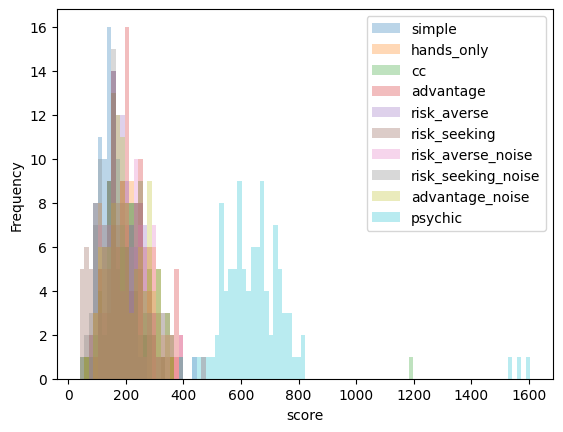

In [120]:
# Display some summary statistics.
import pandas as pd
from scipy import stats

def conf_int(data: np.ndarray, confidence: float=0.95) -> float:
    """Returns confidence interval of estimated mean.

    Args:
        data: values for which mean is to be estimated.
        confidence: probability that reported mean is within returned interval.

    Returns:
        interval: mean of data = mean ± interval, with given confidence.
    """
    mean = data.mean()
    try:
        interval = stats.norm.interval(
            confidence, loc=mean, scale=stats.sem(data))
    except FloatingPointError:
        return np.nan
    return interval[1] - mean
    

# GameInfo is a simple tuple of scores, hands played, and move histories for each game.
scores, hands_played, histories = list(zip(*game_info_list))

hands_played_df = pd.DataFrame(hands_played,
                               columns=[a.name for a in agents], dtype=int)
hp_mean_df = hands_played_df.mean(axis=0).to_frame(name='mean hands played')
hp_mean_df['confidence (p=.95)'] = conf_int(hands_played_df)

scores_df = pd.DataFrame(
    scores, columns=[a.name for a in agents], dtype=int)
scores_mean_df = scores_df.mean(axis=0).to_frame(name='mean score')
scores_mean_df['confidence (p=.95)'] = conf_int(scores_df)

with pd.option_context('display.precision', 1):
    display(hp_mean_df)
with pd.option_context('display.precision', 0):
    display(scores_mean_df)

ax = scores_df.plot.hist(alpha=0.3, bins=100)
_ = ax.set_xlabel('score')

## Estimating Advantage

*Advantage* is the relative value of being further along in the shoe for a given hand given the current shoe contents, remaining hands and game setup.  




# Extra

## Analysis

Here are some analyses using a larger sample size.

## Score distribution

The first set of questions has to do with the distribution of scores across games. This summary is based on 100K games (three deck shoe, no hand limit, short shoes allowed) played by all ten default agents.

A few highlights (excluding psychic):

* **Best score:** *advantage* (240 mean, 225 median)
* **Lowest standard deviation:** *simple* (173), followed by *risk-averse* (197)
* **Most scores above 1000:** *risk-seeking* (0.44%)
* **Games scoring below 100:** about 5%
* **Games *advantage* ranks best:** 23%
* **Games *advantage* ranks worst:** 5%
* **Mean number hands played:** between 19 (simple) to 22.5 (advantage)

,mean score,conf (p=.95),median score,stddev,"pct [1k, 10k]",pct > 10k
simple,168.32,1.07,155,173.11,0.03,0.03
hands_only,219.60,1.36,205,219.05,0.22,0.04
cc,230.45,1.45,215,233.48,0.27,0.05
advantage,239.60,1.48,225,239.05,0.30,0.05
risk_averse,219.07,1.22,205,197.43,0.16,0.03
risk_seeking,178.76,1.70,160,274.51,0.37,0.07
risk_averse_noise,218.56,1.45,205,234.10,0.22,0.05
risk_seeking_noise,194.11,1.61,175,260.41,0.34,0.06
advantage_noise,231.89,1.42,220,229.48,0.25,0.04
psychic,695.94,3.53,645,568.84,2.45,0.29


,mean hands played,conf (p=.95)
simple,18.716,0.004
hands_only,20.429,0.004
cc,20.251,0.004
advantage,22.494,0.004
risk_averse,19.700,0.004
risk_seeking,19.263,0.004
risk_averse_noise,20.393,0.004
risk_seeking_noise,19.542,0.004
advantage_noise,22.494,0.004
psychic,21.786,0.006


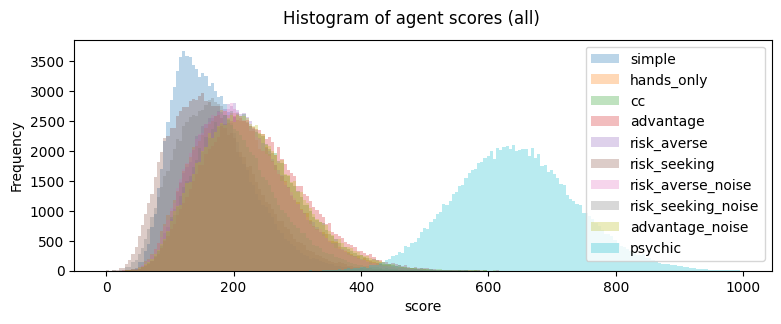

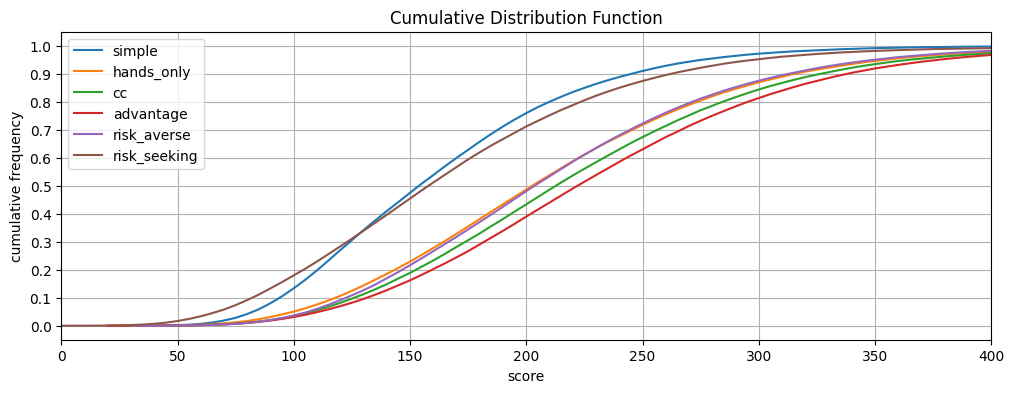

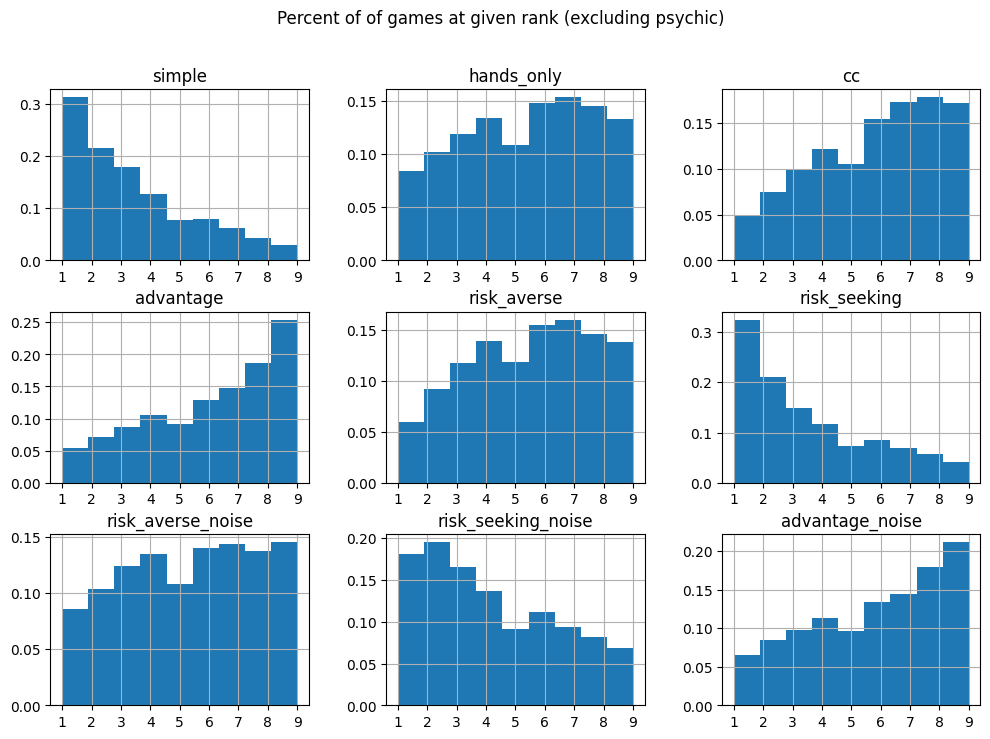

In [115]:
# Display some summary statistics.
import pandas as pd
from matplotlib import pyplot as plt

# Load data
scores_df = pd.read_csv('../data/scores-3deck-10agents-100k.csv')
scores_mean_df = scores_df.mean(axis=0).to_frame(name='mean score')
scores_mean_df['conf (p=.95)'] = conf_int(scores_df)
scores_mean_df['median score'] = scores_df.quantile(.5).astype(int)
scores_mean_df['stddev'] = scores_df.std(ddof=1, axis=0)
scores_mean_df['pct [1k, 10k]'] = ((scores_df >= 1000) & (scores_df < 10000)).mean() * 100
scores_mean_df['pct > 10k'] = (scores_df >= 10000).mean() * 100

with pd.option_context('display.precision', 2):
    display(scores_mean_df)
    
hands_played_df = pd.read_csv('../data/hands-played-3deck-10agents-100k.csv')
hp_mean_df = hands_played_df.mean(axis=0).to_frame(name='mean hands played')
hp_mean_df['conf (p=.95)'] = conf_int(hands_played_df)
with pd.option_context('display.precision', 3):
    display(hp_mean_df)

scores_df[scores_df < 1000].plot.hist(alpha=0.3, bins=200, figsize=(9, 3)).set_xlabel('score')
_ = plt.gcf().suptitle('Histogram of agent scores (all)')
    
# Plot score CDF
ax = None
for col in scores_df.columns[:-4]:
    cumsum = scores_df.groupby(col)[col].agg('count').pipe(pd.DataFrame).rename(columns = {'value': 'frequency'}).cumsum()
    freq = cumsum / scores_df.shape[0]
    ax = freq.plot(ax=ax, xlim=(0, 400), figsize=(12, 4), grid=True, yticks=np.linspace(0, 1, 11))
ax.set_xlabel('score')
ax.set_ylabel('cumulative frequency')
_ = ax.set_title('Cumulative Distribution Function')

# Show how often each agent is at a particular rank
axes = scores_df.iloc[:, :-1].rank(axis=1).hist(figsize=(12, 8), bins=9, density=True)
for ax in axes.flatten():
    ax.set_xticks(np.arange(1, 10))
_ = plt.gcf().suptitle('Percent of of games at given rank (excluding psychic)')

## Payout by remaining shoe size

In [143]:
#@title Setup
import random
from tqdm import notebook

import pandas as pd

from game import card
from game import hand
from game import shoe
from stats import hand_stats
from game import payout_table


def pct_hands_trying_for_straight(
    init_hand: str, target_held_str: str,
    num_trials: int = 100, num_decks: int = 3,
    min_payout: int = 30, max_payout: int = 100):
  delt = hand.Hand(init_hand)
  target_held = hand.Hand(target_held_str)  
  card_list = shoe.Shoe.shoe_excluding_cards(
    delt.cards, num_decks=num_decks).cards
  shoe_sizes = np.linspace(5, len(card_list), 5).astype(int)
  straight_values = np.arange(min_payout, max_payout+1, 10)
  out = pd.DataFrame(data=0, index=straight_values, columns=shoe_sizes)

  for trial in notebook.trange(num_trials):
    for shoe_size in shoe_sizes:
      random.shuffle(card_list)
      for straight_value in straight_values:
        payout_t = payout_table.PayoutTable(
            10000, 1000, 200, 80, 70, 60, straight_value, 20, 15, 10, 0)
        ps = hand_stats.HandStats(card_list[:shoe_size], payout=payout_t)
        hv = ps.best_expected_payout(delt)
        if hv.held == target_held:
          out.loc[straight_value, shoe_size] += 1
          break
  return 100 * out.cumsum(axis=0) / num_trials

def plot_pct_hands(data, desc, num_decks, ax=None):
  data.plot(ax=ax, grid=True)
  ax.set_xlabel('Payout for straight')
  ax.set_ylabel('% try straight')
  ax.set_title(f'{desc} ({num_decks} decks)')  

In [144]:
#@title Run trials
num_trials = 100 #@param {type:"integer"}

inside = pct_hands_trying_for_straight(
    '2C 4D 5H 6S KC', '2C 4D 5H 6S', num_trials, num_decks=3)
outside = pct_hands_trying_for_straight(
    '2C 3D 4D 5H KC', '2C 3D 4D 5H', num_trials, num_decks=3)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

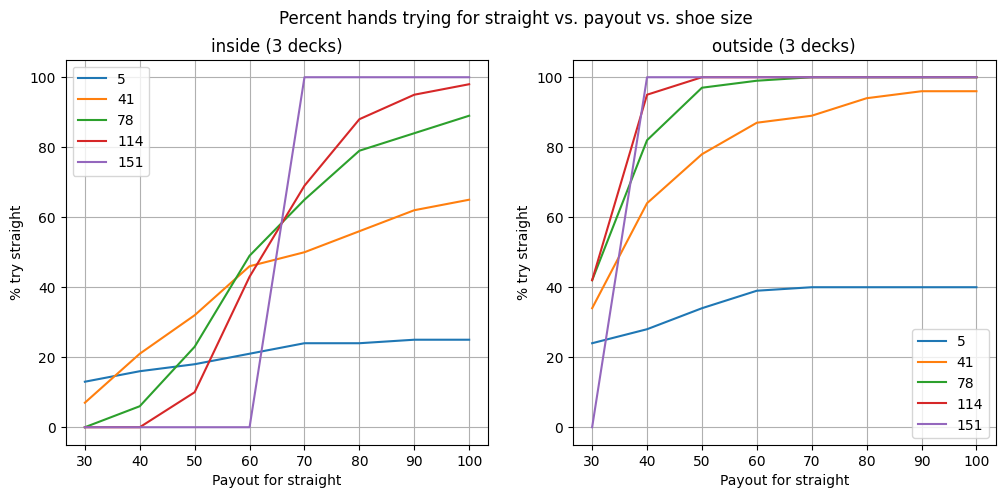

In [145]:
#@title Plot
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
plot_pct_hands(inside, desc='inside', num_decks=3, ax=axes[0])
plot_pct_hands(outside, desc='outside', num_decks=3, ax=axes[1])

_ = fig.suptitle(
    'Percent hands trying for straight vs. payout vs. shoe size')

In [26]:
import pandas as pd

scores_df = pd.read_csv('../data/scores-3deck-10agents-70k.csv')
scores_norm = scores_df / np.array(scores_df['psychic'])[:, np.newaxis]
scores_mean_norm = scores_norm.mean(axis=0).to_frame(name='mean score') 
scores_mean_norm['stddev'] = scores_norm.std(ddof=1, axis=0)
scores_mean_norm * 696.19


,mean score,stddev
simple,176.049973,61.643612
hands_only,227.212172,76.925100
cc,237.689563,77.818342
advantage,246.976962,79.728186
risk_averse,227.737915,73.557263
risk_seeking,180.062276,73.425834
risk_averse_noise,225.643612,75.555929
risk_seeking_noise,197.323828,75.108170
advantage_noise,239.045551,78.414132
psychic,696.190000,0.000000


In [24]:
import numpy as np
scores_norm = scores_df / np.array(scores_df['psychic'])[:, np.newaxis]


,simple,hands_only,cc,advantage,risk_averse,risk_seeking,risk_averse_noise,risk_seeking_noise,advantage_noise,psychic
0,0.146154,0.484615,0.230769,0.484615,0.276923,0.169231,0.438462,0.153846,0.300000,1.0
1,0.473282,0.458015,0.320611,0.458015,0.358779,0.389313,0.251908,0.541985,0.320611,1.0
2,0.188679,0.477987,0.276730,0.194969,0.333333,0.358491,0.427673,0.308176,0.408805,1.0
3,0.276596,0.375887,0.319149,0.347518,0.319149,0.312057,0.319149,0.262411,0.368794,1.0
4,0.266667,0.525000,0.533333,0.450000,0.533333,0.391667,0.616667,0.350000,0.425000,1.0
...,...,...,...,...,...,...,...,...,...,...
69995,0.458015,0.251908,0.206107,0.442748,0.190840,0.259542,0.236641,0.412214,0.312977,1.0
69996,0.217054,0.193798,0.209302,0.465116,0.341085,0.333333,0.302326,0.248062,0.465116,1.0
69997,0.256410,0.448718,0.397436,0.487179,0.320513,0.262821,0.506410,0.346154,0.326923,1.0
69998,0.178295,0.325581,0.403101,0.263566,0.372093,0.263566,0.364341,0.364341,0.488372,1.0


### Calculationg target scores

The current iteration of [Countdown Video Poker](https://countdownvideopoker.com/) is presented as a daily challenge, where players can try a new shoe each day. All players to the page will get the same shoe on a given day, and players may replay a shoe to try to improve their score. At the end of the game players are presented with their score (total winnings) and a breakdown of how good their score is for that day's shoe (one through four stars). The scores that correspond to each of the four levels are called the *target scores*, and since shoes are random there's a good deal of variation in what constitutes a "good" score on any given day.

We compute target scores as follows:
1. Play the given shoe using ten different agents, as shown above.
2. Sort the scores.
3. Report the 2nd, 4th, 6th and 8th score as the targets for one through four stars.

An example for the scores computed above follows:

In [5]:
# Computing targets from multiple agent scores.
targets = pd.DataFrame(np.sort(scores_df).take([1, 3, 5, 7], axis=1),
                       columns=['*', '**', '***', '****'])

# Make sure there aren't any duplicate targets by reducing the lower target.
targets['***'] = np.where(targets['***'] >= targets['****'],
                             targets['****'] - 10, targets['***'])
targets['**'] = np.where(targets['**'] >= targets['***'],
                             targets['***'] - 10, targets['**'])
targets['*'] = np.where(targets['*'] >= targets['**'],
                             targets['**'] - 10, targets['*'])
assert not np.any(targets.diff(axis=1) <= 0)

targets

,*,**,***,****
0,165,290,300,355
1,125,140,150,210
2,150,220,230,335
3,170,185,230,255
4,100,115,155,190
...,...,...,...,...
95,120,220,230,270
96,195,225,240,255
97,115,120,140,165
98,165,195,230,250


In [4]:
# Alternatively, just use the compute_targets method.
from stats import shoe_stats

targets_array = shoe_stats.compute_targets(scores_df, ranks=[1, 3, 5, 7])
pd.DataFrame(targets_array, columns=['*', '**', '***', '****'])

,*,**,***,****
0,165,290,300,355
1,125,140,150,210
2,150,220,230,335
3,170,185,230,255
4,100,115,155,190
...,...,...,...,...
95,120,220,230,270
96,195,225,240,255
97,115,120,140,165
98,165,195,230,250


In [9]:
hands_played = pd.read_csv('../data/hands-played-3deck-10agents-70k.csv')
scores = pd.read_csv('../data/scores-3deck-10agents-70k.csv')
scores

,simple,hands_only,cc,advantage,risk_averse,risk_seeking,risk_averse_noise,risk_seeking_noise,advantage_noise,psychic
0,95,315,150,315,180,110,285,100,195,650
1,310,300,210,300,235,255,165,355,210,655
2,150,380,220,155,265,285,340,245,325,795
3,195,265,225,245,225,220,225,185,260,705
4,160,315,320,270,320,235,370,210,255,600
...,...,...,...,...,...,...,...,...,...,...
69995,300,165,135,290,125,170,155,270,205,655
69996,140,125,135,300,220,215,195,160,300,645
69997,200,350,310,380,250,205,395,270,255,780
69998,115,210,260,170,240,170,235,235,315,645


In [8]:
display(scores.mean(axis=0))
conf_int(scores)

simple                169.013143
hands_only            220.392786
cc                    230.771143
advantage             240.116071
risk_averse           218.894714
risk_seeking          179.234071
risk_averse_noise     219.250214
risk_seeking_noise    194.262286
advantage_noise       231.797429
psychic               696.187714
dtype: float64

simple                1.421538
hands_only            1.695610
cc                    1.771930
advantage             1.842885
risk_averse           1.452091
risk_seeking          2.111360
risk_averse_noise     1.783834
risk_seeking_noise    1.945751
advantage_noise       1.750067
psychic               4.234212
dtype: float64

## Gathering statistics from multiple games

The *shoe_stats* module includes functions for playing multiple games in parallel using Python's multiprocessing.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.01it/s]


,simple,cc
0,200,255
1,110,110
2,225,175
3,110,170
4,180,280
...,...,...
95,135,170
96,110,80
97,115,155
98,105,150


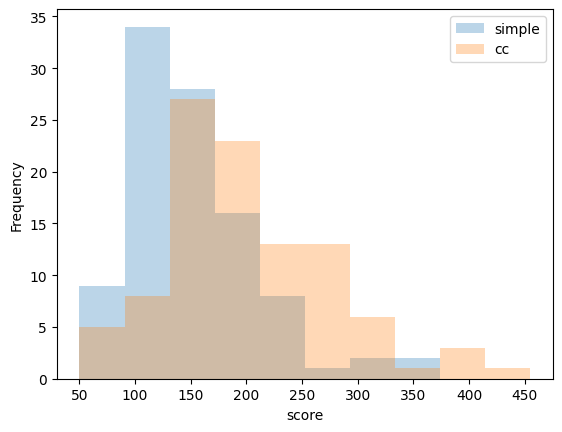

In [10]:
import numpy as np
import pandas as pd

from game import poker_game
from agent import player_agent
from game import shoe
from stats import shoe_stats

# Generate a list of games
num_trials = 100
num_decks = 3

# Create a list of games with random shoes.
seeds = np.random.SeedSequence(entropy=123456).spawn(num_trials)
games = [poker_game.PokerGame(num_decks=num_decks,
                              draw_shoe=shoe.Shoe(num_decks=num_decks, seed=seed))
         for seed in seeds]

# Create agents to play the game. Note that each agent will play in its own copy,
# so use the returned values rather than relying on fields set in the game objects.
agents = [player_agent.SimplePlayerAgent(name='simple'),
          player_agent.CardCountingAgent(name='cc')]
game_info_list = shoe_stats.play_games(games, agents)

scores = [game_info[0] for game_info in game_info_list]
scores_df = pd.DataFrame(scores, columns=[a.name for a in agents], dtype=int)
scores_df.plot.hist(alpha=0.3).set_xlabel('score')

scores_df

In [11]:
# Extract number of hands played
hands_played = [game_info[1] for game_info in game_info_list]
hands_played_df = pd.DataFrame(hands_played, columns=[a.name for a in agents], dtype=int)
hands_played_df.mean(axis=0)

simple    18.09
cc        19.61
dtype: float64

## Computing target scores

Running a larger set of agents on a game will give a range of scores from which you
can compute target values for *OK*, *good*, *better*, *great*, etc.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:09<00:00,  1.29s/it]


simple                18.66
hands_only            20.41
cc                    20.13
advantage             22.47
risk_averse           19.62
risk_seeking          19.18
risk_averse_noise     20.46
risk_seeking_noise    19.53
advantage_noise       22.55
psychic               21.81
dtype: float64

,simple,hands_only,cc,advantage,risk_averse,risk_seeking,risk_averse_noise,risk_seeking_noise,advantage_noise,psychic
0,200,240,270,280,335,115,315,120,280,775
1,120,100,180,130,195,135,185,125,160,520
2,235,190,185,110,215,205,130,185,145,780
3,110,225,170,150,115,70,105,95,85,610
4,180,230,280,325,175,285,370,200,285,595
...,...,...,...,...,...,...,...,...,...,...
95,135,280,170,190,155,170,285,160,175,660
96,110,300,80,155,125,90,100,85,265,490
97,125,185,175,280,130,70,155,110,180,1425
98,105,135,150,305,180,200,145,245,165,560


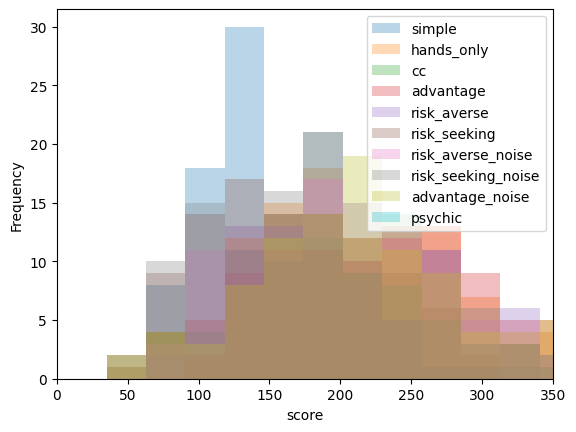

In [1]:
import numpy as np
import pandas as pd

from game import poker_game
from agent import player_agent
from game import shoe
from stats import shoe_stats

# Generate a list of games
num_trials = 100
num_decks = 3

# Create a list of games with random shoes.
seeds = np.random.SeedSequence(entropy=123456).spawn(num_trials)
games = [poker_game.PokerGame(draw_shoe=shoe.Shoe(num_decks=num_decks, seed=seed),
                              allow_short_shoe=True)
         for seed in seeds]

# Create agents to play the game. Note that each agent will play in its own copy,
# so use the returned values rather than relying on fields set in the game objects.
agents = shoe_stats.default_target_agents(num_decks=num_decks)
game_info_list = shoe_stats.play_games(games, agents)

scores = [game_info[0] for game_info in game_info_list]
scores_df = pd.DataFrame(scores, columns=[a.name for a in agents], dtype=int)
ax = scores_df.plot.hist(alpha=0.3, bins=50, figsize=(12, 8))
ax.set_xlabel('score')
ax.set_xlim(0, 350)

hands_played = [game_info[1] for game_info in game_info_list]
hands_played_df = pd.DataFrame(hands_played, columns=[a.name for a in agents], dtype=int)
display(hands_played_df.mean(axis=0))

scores_df

simple                18.66
hands_only            20.41
cc                    20.13
advantage             22.47
risk_averse           19.62
risk_seeking          19.18
risk_averse_noise     20.46
risk_seeking_noise    19.53
advantage_noise       22.55
psychic               21.81
dtype: float64

,simple,hands_only,cc,advantage,risk_averse,risk_seeking,risk_averse_noise,risk_seeking_noise,advantage_noise,psychic
0,200,240,270,280,335,115,315,120,280,775
1,120,100,180,130,195,135,185,125,160,520
2,235,190,185,110,215,205,130,185,145,780
3,110,225,170,150,115,70,105,95,85,610
4,180,230,280,325,175,285,370,200,285,595
...,...,...,...,...,...,...,...,...,...,...
95,135,280,170,190,155,170,285,160,175,660
96,110,300,80,155,125,90,100,85,265,490
97,125,185,175,280,130,70,155,110,180,1425
98,105,135,150,305,180,200,145,245,165,560


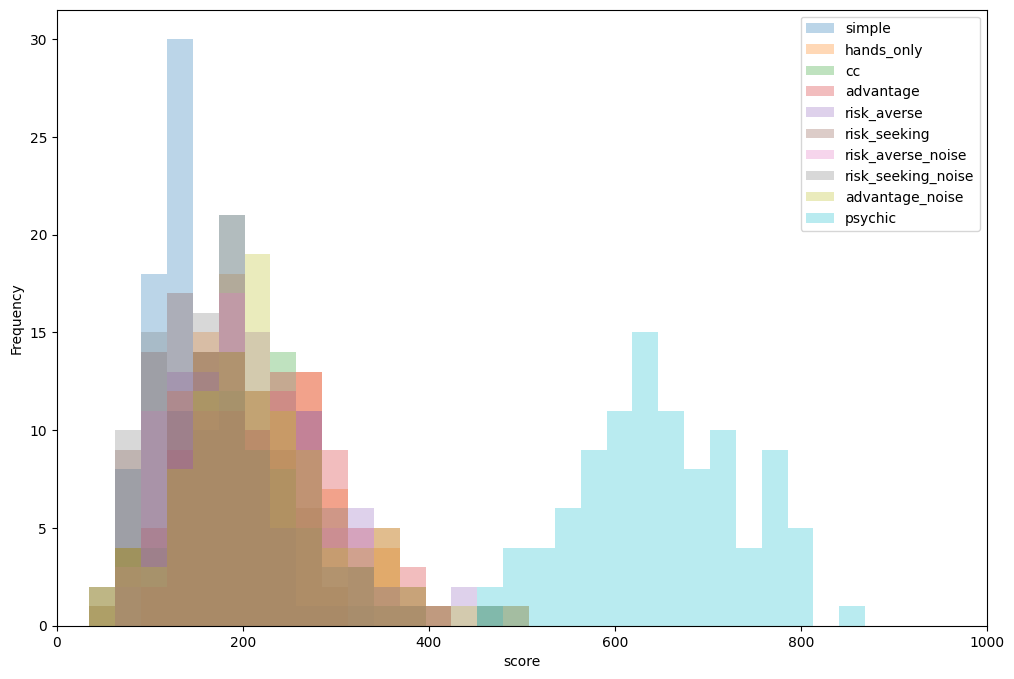

In [47]:
ax = scores_df.plot.hist(alpha=0.3, bins=50, figsize=(12, 8))
ax.set_xlabel('score')
ax.set_xlim(0, 1000)

hands_played = [game_info[1] for game_info in game_info_list]
hands_played_df = pd.DataFrame(hands_played, columns=[a.name for a in agents], dtype=int)
display(hands_played_df.mean(axis=0))

scores_df

In [29]:
scores_df.rank(axis=1).mean(axis=0)

simple                 3.105
hands_only             5.445
cc                     5.480
advantage              6.155
risk_averse            5.790
risk_seeking           3.855
risk_averse_noise      5.375
risk_seeking_noise     4.045
advantage_noise        5.750
psychic               10.000
dtype: float64

<AxesSubplot: ylabel='Frequency'>

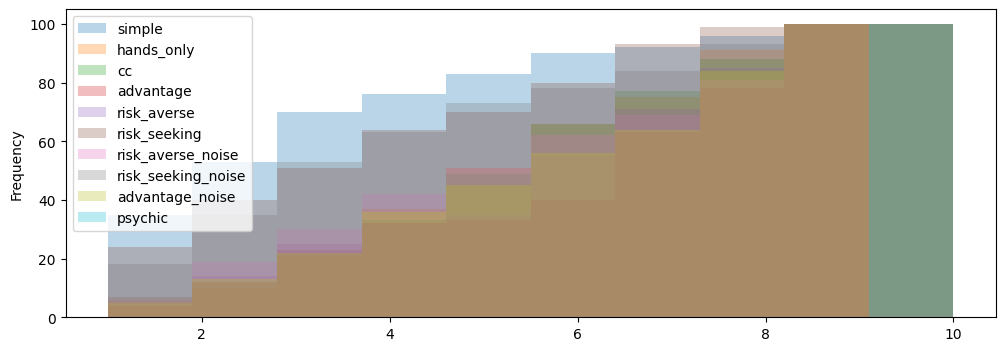

In [43]:
scores_df.rank(axis=1).plot.hist(cumulative=True, alpha=0.3, figsize=(12, 4))

In [81]:
data = {
    'mean': scores_df.mean(axis=0),
    'stddev': scores_df.std(axis=0, ddof=1),
    '%>1k': ((scores_df >= 1000) & (scores_df < 10000)).mean() * 100,
    '%>10k': (scores_df > 10000).mean() * 100,
    'mean rank': scores_df.rank(axis=1).mean(axis=0),
    'median rank': scores_df.rank(axis=1).quantile(.5, axis=0)
    }
with pd.option_context('display.precision', 1):
    display(pd.DataFrame(data))


,mean,stddev,%>1k,%>10k,mean rank,median rank
simple,155.7,60.0,0.0,0.0,3.1,2.2
hands_only,207.3,66.0,0.0,0.0,5.4,5.0
cc,208.6,72.9,0.0,0.0,5.5,5.5
advantage,229.9,81.1,0.0,0.0,6.2,7.0
risk_averse,211.2,77.3,0.0,0.0,5.8,6.0
risk_seeking,173.1,73.7,0.0,0.0,3.9,3.5
risk_averse_noise,205.2,75.2,0.0,0.0,5.4,5.0
risk_seeking_noise,179.0,78.9,0.0,0.0,4.0,3.2
advantage_noise,218.8,84.4,0.0,0.0,5.8,6.0
psychic,656.4,116.9,1.0,0.0,10.0,10.0


In [99]:
ranked = scores_df.quantile(np.linspace(0, 1, 11), axis=1)
ranked.index = np.arange(11)

collisions = np.hstack(
    [(ranked.loc[1, :] == ranked.loc[3, :]).mean(),
     (ranked.loc[3, :] == ranked.loc[5, :]).mean(),
     (ranked.loc[5, :] == ranked.loc[7, :]).mean(),
     (ranked.loc[7, :] == ranked.loc[9, :]).mean()])
print(f'collisions of sequential odd ranks: {collisions * 100}')

mean_ranks = ranked.mean(axis=1).to_frame()
mean_ranks.index.rename('rank', inplace=True)
mean_ranks.columns = ['mean score']
mean_ranks

collisions of sequential odd ranks: [0. 0. 0. 0.]


,mean score
rank,
0,118.0
1,140.5
2,157.6
3,174.4
4,189.8
5,204.4
6,220.8
7,239.4
8,261.4


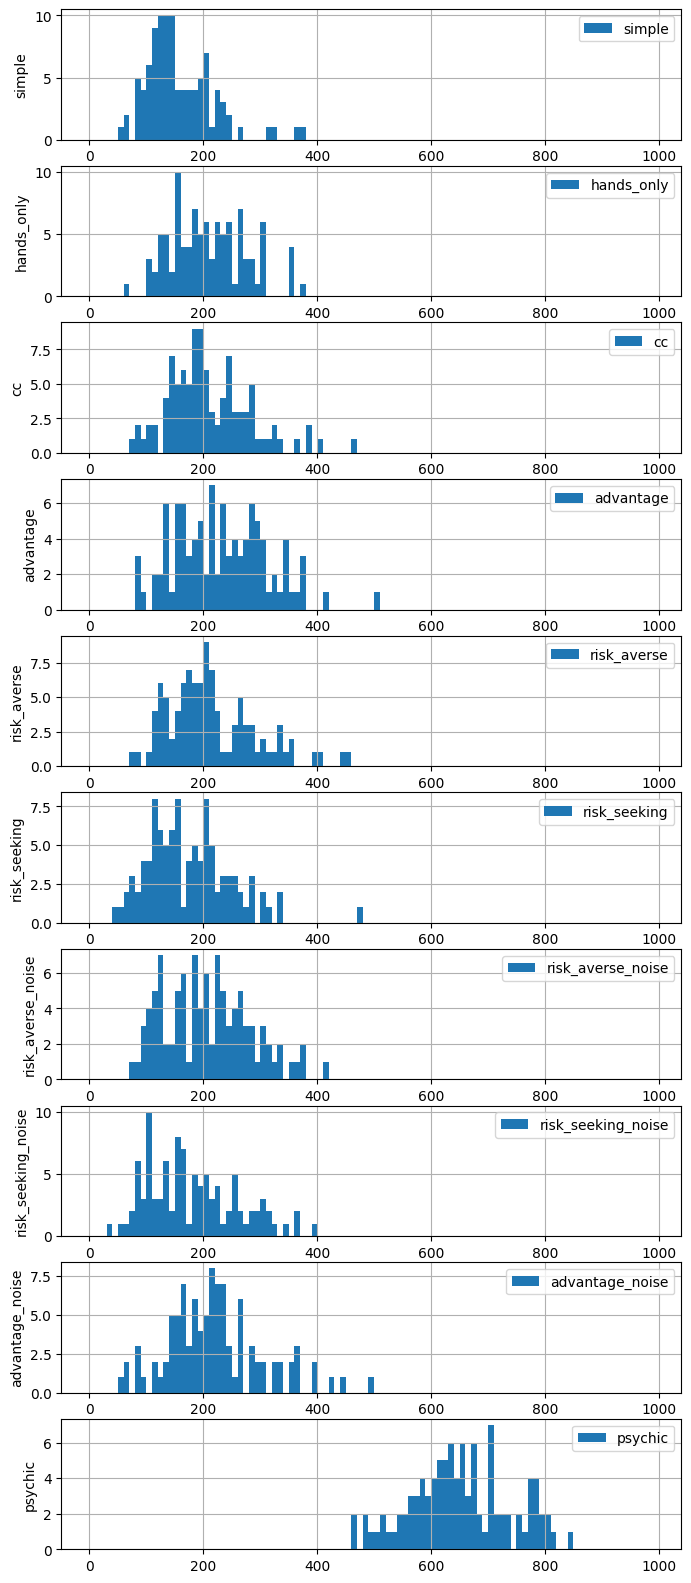

In [17]:
from matplotlib import pyplot as plt

BIN_SIZE = 10
fig, axes = plt.subplots(nrows=scores_df.shape[1], figsize=(8, 20))
for i, col in enumerate(scores_df.columns):
    data = scores_df[col]
    ax = data[data < 1000].plot.hist(bins=np.arange(0, 1000, BIN_SIZE),
                                     legend='best', grid=True, ax=axes[i])
    ax.set_ylabel(col)
    


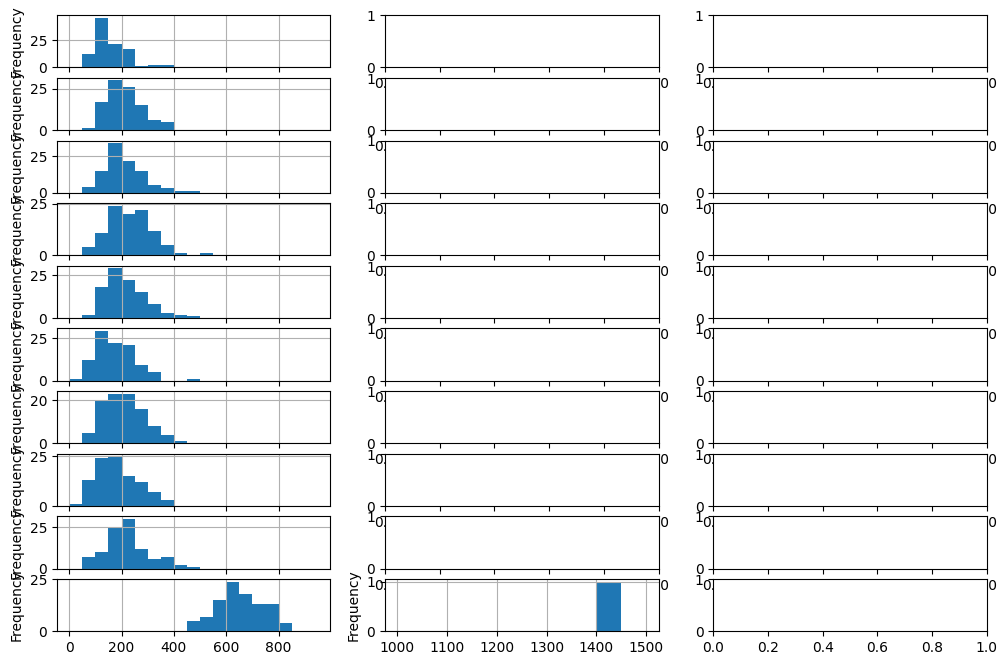

In [8]:
from matplotlib import pyplot as plt

BIN_SIZE = 50
fig, axes = plt.subplots(nrows=scores_df.shape[1], ncols=3, figsize=(12, 8))
for i, col in enumerate(scores_df.columns):
    data = scores_df[col]
    data[data < 1000].plot.hist(bins=np.arange(0, 1000, BIN_SIZE), legend=None, grid=True, ax=axes[i][0])
    if np.any((data >= 1000) & (data < 10000)):
        data[(data >= 1000) & (data < 10000)].plot.hist(bins=np.arange(1000, 1501, BIN_SIZE), legend=None, grid=True, ax=axes[i][1])
    if np.any(data >= 10000):
        data[data >= 10000].plot.hist(bins=np.arange(10000, 10501, BIN_SIZE), legend=None, grid=True, ax=axes[i][2])




In [ ]:
for ax in axes:
    ax.set_xlabel('score')
axes[0].set_title('score < 1000 (99.67%)')
axes[1].set_title('1000 ≤ score < 10000 (0.29%)')
axes[2].set_title('10000 ≥ score (0.04%)')
fig.suptitle('AdvBot score distribution (3-deck shoe with 10-card minimum). Mean = 229')
fig.subplots_adjust(top=0.85)

In [1]:
import numpy as np
import pandas as pd

from game import poker_game
from agent import player_agent
from game import shoe
from stats import shoe_stats

# Generate a list of games
num_trials = 25000
num_decks = 3

# Create a list of games with random shoes.
seeds = np.random.SeedSequence(entropy=1234567).spawn(num_trials)
games = [poker_game.PokerGame(num_decks=num_decks,
                              draw_shoe=shoe.Shoe(num_decks=num_decks, seed=seed),
                              allow_short_shoe=True)
         for seed in seeds]

# Create agents to play the game. Note that each agent will play in its own copy,
# so use the returned values rather than relying on fields set in the game objects.
agents = shoe_stats.default_target_agents(num_decks=num_decks)
game_info_list = shoe_stats.play_games(games, agents)

scores = [game_info[0] for game_info in game_info_list]
scores_df = pd.DataFrame(scores, columns=[a.name for a in agents], dtype=int)
ax = scores_df.plot.hist(alpha=0.3, bins=50)
ax.set_xlabel('score')
ax.set_xlim(0, 350)

hands_played = [game_info[1] for game_info in game_info_list]
hands_played_df = pd.DataFrame(hands_played, columns=[a.name for a in agents], dtype=int)
display(hands_played_df.mean(axis=0))

hands_played_df.to_csv('/Users/bug/Projects/GitHub/one-shoe-poker/data/hands-played-3deck-10agents-25k.csv',
                       index=False, header=True)
scores_df.to_csv('/Users/bug/Projects/GitHub/one-shoe-poker/data/scores-3deck-10agents-25k.csv',
                 index=False, header=True)


  1%|▋                                                                                                       | 176/25000 [03:56<6:32:22,  1.05it/s]Process SpawnPoolWorker-6:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-7:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Librar

KeyboardInterrupt: 

In [16]:
scores_df.to_csv('/Users/bug/Projects/GitHub/one-shoe-poker/data/scores-3deck-10agents.csv',
                 index=False, header=True)

In [13]:
display(hands_played_df.mean(axis=0))
scores_df.mean(axis=0)

simple                18.08
hands_only            19.78
cc                    19.63
risk_averse           19.07
risk_seeking          18.65
risk_averse           19.07
risk_seeking          18.65
risk_averse_noise     19.82
risk_seeking_noise    18.96
advantage             21.48
psychic               21.26
dtype: float64

simple                159.95
hands_only            207.70
cc                    209.10
risk_averse           204.60
risk_seeking          162.65
risk_averse           204.60
risk_seeking          162.65
risk_averse_noise     207.40
risk_seeking_noise    175.55
advantage             232.15
psychic               647.05
dtype: float64

In [7]:
scores_df_1k = scores_df
hands_played_df_1k = hands_played_df

# Technical details

## Estimating advantage

It's not feasable to compute the exact expected reward across an entire game like we did for a single hand, so we're going to have to use sampling to estimate the value of a particular strategy. This falls into the area of [reinforcement learning](https://en.wikipedia.org/wiki/Reinforcement_learning), a subset of machine learning that deals with learning how to perform a task by playing through lots of examples and learning what leads to the highest rewards.

On any given turn an agent has access to an initial 5-card hand plus the contents (but not order) of the remaining shoe. In theory you could just bundle up these values into a state vector and train up a neural net using your favorite reinforcement-learning algorithm, but there are some significant headwinds to this approach. For a three-deck shoe there are over 10^37 possible input states (~3.7 million possible unique hands times 4^52 shoes) and 32 possible actions. That's large but not completely outside the realm of what modern RL techniques can handle, but the bigger issue is that the reward signal has a very high variance, which means we would need a *lot* of data to converge on anything useful.

Luckily, there is a better way.

### Recasting as a simpler game

A key insight is that while which cards are held back affects the expected reward on any given hand, only the *number* of cards held affects subsequent hands. For example, if my initial hand is 4♣10♣Q♣K♡A♣, I might try for a flush by discarding the King or try for an inside straight by discarding the Four. These would have different expected immediate reward but in either case my next hand would start one card further into the shoe than it is now, and all the cards in my hand plus the top card of the deck will be discarded regardless of my choice. (Note that my immediate reward and subsequent hands aren't independent — for example if I win with a straight it means there's one fewer Jack in the shoe for subsequent hands. But that Jack is going to come up next regardless of which cards I decide to hold.)

This means we can split the problem into two separate computations, one for the expected payout on the current hand (which we can compute exactly) and one for the additional advantage of holding a certain number of cards. We still can't compute advantage exactly, but we've eliminated the hand from the input space and reduced the output space to six actions.

More formally, we want to compute the following functions:

* $R_e(H, S)$: expected reward (payout) when holding the set of cards $H$ and then drawing back up to five cards from shoe $S$, where $|H|$ is between zero and five.

* $A(S, \lambda, h)$: the expected _relative advantage_ of holding $h$ cards given remaining shoe $S$ and remaining hand limit $\lambda$.

Putting it in reinforcement learning terms.

Note that this is not the usual definition for *advantage* talked about in most reinforcement learning

# Agents

Agents are processes that automatically play 



### HandStats

The core of the toolkit is the HandStats class, which computes the expected value of 

## Countdown Poker Analysis Toolkit

The Countdown Poker Analysis Toolkit (which this notebook is a part of) is a Python library for analyzing hands in Countdown Poker, and more generally for writing agents to play the game. Most of the heavy lifting is implemented in the repo and not this notebook, so check there for more details on how things work under the hood. The code is fairly well commented.

The toolkit has three parts:

### Game

Modules and classes that implement the game itself.

* **Card:** a single playing card, comprising a rank and suit. Can be initialized either with a rank (1 to 13) and suit enum or as a string of the form '\<rank\>\<suit\>' where \<rank\> is one of {A, 2-10, J, Q, K} and \<suit\> is one of {C, D, H, S}.
* **Hand:** a hand of up to five cards. Hands can be initialized either with a list of Cards or as a space-separated string of cards (e.g. 'AS 2C 5H KD 4C').
* **Shoe:** ordered list of cards from one or more decks.
* **PayoutTable:** payouts for each type of winning hand. PayoutTable.default() returns the default table shown above.
* **PokerGame:** class that implements the game itself.

### Stats

Modules for computing statistics of a particular hand, game or set of games. The main class is **HandStats**, which calculates the probability and/or expected payout for a particular hand and shoe contents.

### Agents

Classes that play a game using a given heuristic. The normal analysis uses ten predefined agents:

* **simple:** holds any cards that already form a paying hand (e.g. pair of Jacks) and discards the rest. If initial hand has zero payout then hold onto Jack and higher cards and discard the rest.
* **hand:** maximizes expected payout for each hand based only on the current hand (and number of decks being played), but not which cards are still in the shoe.
* **card-count:** maximizes expected payout for each hand based on both the current hand and the set of cards remaining in the shoe (but not their order).
* **risk-averse:** maximizes payout of the current hand while simultaneously minimizing downside risk. Uses risk tolerance of -1 (equal trade-off of current payout and downside semi-deviance).
* **risk-seeking:** maximizes payout of the current hand while simultaneously maximizing upside risk.  Uses risk tolerance of +1 (equal trade-off of current payout and upside semi-deviance).
* **card-count + noise:** same as card-count, but injects a small amount of noise into the process. 
* **risk-averse + noise:** risk-averse (risk tolerance -0.5) and injects a small amount of noise into the process.
* **risk-seeking + noise:** risk-seeking (risk tolerance +0.5) and injects a small amount of noise into the process. 
* **advantage:** tries to maximize the expected payout of the entire game, trading off holding more (or fewer) cards than would be optimal for the current hand if it improves the expected payout of the game overall. For hand-limited games the agent will discard more cards so future hands are further into the shoe; for unlimited games it will tend to discard fewer cards in order to play more hands overall. This agent must be trained for a specific payout table and deck size, and is currently trained for 2, 3, and 4 decks with the default table.
* **psychic:** optimal play given complete knowledge, including card order in the shoe. This is the maximum possible score for a shoe.




## Agents



## Target Scores

The current iteration of [Countdown Video Poker](https://countdownvideopoker.com/) is presented as a daily challenge, where players can try a new shoe each day. All players to the page will get the same shoe on a given day, and players may replay a shoe to try to improve their score. At the end of the game players are presented with their score (total winnings) and a breakdown of how good that score is for that day's shoe (one through four stars).



This section plays specified card shoes using agents of various skill levels and records the score they get. We currently have four agents. These roughly correspond to *ok*, *good*, *great*, and *best*, but because the first three agents work with incomplete knowledge it's possible for the first three scores to be in any order for a particular shoe. The *Psychic* agent cheats and always reports the absolute highest possible hand on any given shoe.

* **simple:** holds any cards that already form a paying hand (e.g. pair of Jacks) and discards the rest. If initial hand has zero payout then hold onto Jack and higher cards and discard the rest.
* **hand:** maximizes expected payout for each hand based only on the current hand (and number of decks being played), but not which cards are still in the shoe.
* **card_count:** maximizes expected payout for each hand based on both the current hand and cards remaining in the shoe, but not the order of those cards.
* **psychic:** optimal play given complete knowledge, including card order in the shoe. This is the maximum possible score for a shoe.

### Input format

Shoes are specified in the JSON format produced by the Over/Under implementation (Build 0.6.17 and later), and have the following format:

    [{seed: <int>, deck:[{rank: <int>, suit: <int>}, ...]},
     {seed: <int>, deck:[{rank: <int>, suit: <int>}, ...]},
     ...]

Ace is represented as rank 14, and *suit* will be one of (1, 4, 8, 16), which corresponds to spades, clubs, hearts and diamonds respectively.

## Output format

Output will be a JSON string formatted as:

    [{"<seed1>", [<target1>, <target2>, <target3>, <target4>]},
     {"<seed2>", [<target1>, <target2>, <target3>, <target4>]},
      ...]

where targets are presented in agent order (i.e. "good" to "best"). Note that the output does not include the number of decks in the shoe, so be sure to associate the output with the correct input.


## How much room is there for improvement?

Before going into more detailed strategy let's get sense of what a simple heuristics-base agent might score in a game and also what the highest possible score would be. That way we know how much headroom there is for improved play.

We'll set up two agents, a simple baseline agent that holds any cards that are already giving points (or Jack+ if no points), and a "psychic" agent that cheats by looking at the exact order of cards in the shoe and holding cards that maximize the payout for the entire game.

In [ ]:
#@title Create random games for analysis
num_trials = 100  #@param {type:"integer"}
num_decks = 2  #@param {type:"integer"}
hand_limit = 0  #@param {type:"integer"}
seed = 12345  #@param {type:"integer"}

payout = payout_table.PayoutTable.default()
games_q = collections.deque()

for trial in range(num_trials):
  draw_shoe = shoe.Shoe(num_decks=num_decks, seed=seed + trial)
  games_q.append(poker_game.PokerGame(
      num_decks=num_decks, payout=payout,
      hand_limit=hand_limit,
      draw_shoe=draw_shoe))
games = list(games_q)


### Simulating multiple games

In [ ]:
#@title Play games with all seven agents
from stats import shoe_stats

payouts_q = collections.deque()

for trial in notebook.trange(num_trials):
  game = games[trial].copy()
  payouts_q.append(shoe_stats._target_scores_extended(game))
agent_scores = np.array(payouts_q)


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

np.set_printoptions(precision=0, suppress=True)
print(agent_scores.std(axis=0).astype(int))
print(agent_scores.mean(axis=0).astype(int))

scores_df = pd.DataFrame(agent_scores, columns=['simple', 'hand', 'cc', '-risk', '+risk', 'adv', 'cheater'])
scores_df

[  44 1005   53   55 1410   53 1392]
[ 95 214 121 118 286 131 584]


,simple,hand,cc,-risk,+risk,adv,cheater
0,125,135,105,110,60,80,365
1,70,80,95,145,115,145,370
2,115,155,140,180,85,125,455
3,60,110,120,175,170,100,465
4,95,100,130,325,120,200,455
...,...,...,...,...,...,...,...
95,50,75,105,75,55,170,415
96,60,135,130,85,65,145,335
97,70,150,195,80,150,155,415
98,80,80,80,85,10,65,395


In [ ]:
pd.DataFrame(scores_df.rank(axis=1).mean(axis=0), columns=['rank'])

,rank
simple,2.745
hand,3.675
cc,3.930
-risk,3.870
+risk,2.520
adv,4.260
cheater,7.000


In [ ]:
(scores_df > 1000).sum(axis=0)

simple     0
hand       1
cc         0
-risk      0
+risk      2
adv        0
cheater    2
dtype: int64

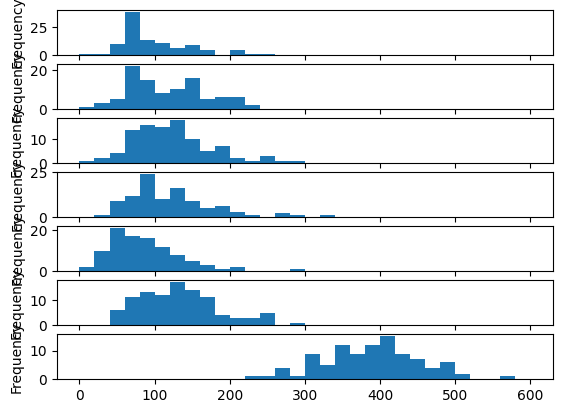

In [ ]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(nrows=len(scores_df.columns))
for i, c in enumerate(scores_df.columns):
  _ = scores_df[c].plot.hist(range=(0, 600), bins=30, ax=axes[i])


In [ ]:
card_str = '4C AC 2C KS 9C KD 8H 7C JS 10D 2H 5H QS 7D 3D QD 8C QH 2H QC 6D 10S QH QC 9H 6H QD KC 3H 7C 6S  9S 3H AH 9C 9D 10C AH 9H JS KH AD 6H 7S 6S 7H 5S 8S JD 8H QD 2H 5D AS 2C 6H 6S 5H 5C QC 9H JD 2C 4C 7H 7H 4C 7S QH KS JH 5S 2D 4C JD KS 7D 4D 8H JH 6C JS 3C QH 3C 5S 8D 4H AH 5H QS 4D 9C 10C  10D 6D 6C 2S 7H 9S 2D KH 4D KD 10H 8D 5C 6S KC 8C 8S 8C 4S KD 3S 10H AD 8S 9D 4S KS 8S AS AC QS 7C 6C 4S 3H 4D 5D 3S 3D 4H 8C 2D 6D KD 10C 7D 4H 10D 10H 9D 4H 5C QC KH 9D JD 9S JS QD 8H 8D 8D 5S 3H AC AS JC 7S 10H JC JH 9C 10S 6D 3D  6C 5C AD 4S 3S 2S 7D AC 5H 7S KC 5D KC AS JC JC 10S 3C 9S 10D 2S AD JH 3C 2H 2S 2D 6H QS KH 5D 3D 9H 10C 10S 7C 3S 2C AH'
game = poker_game.PokerGame(num_decks=4, draw_shoe=shoe.Shoe(card_str))
scores = shoe_stats._target_scores_extended(game)
scores

IndexError: ignored

In [ ]:
#@title Play games with Simple agent
payouts_q = collections.deque()

for trial in notebook.trange(num_trials):
  game = games[trial].copy()
  agent = simple_player.SimplePlayerAgent(payout=payout, verbose=False)
  _ = agent.play(game)
  payouts_q.append(game.score)
simple = np.array(payouts_q)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
#@title Play games with Psychic Agent (optimal play)
payouts_q = collections.deque()

for trial in notebook.trange(num_trials):
  game = games[trial].copy()
  agent = player_agent.PsychicAgent(
      game.draw_shoe.cards, hand_limit=hand_limit, payout=payout, verbose=False)
  _ = agent.play(game)
  payouts_q.append(game.score)
optimal = np.array(payouts_q)

  0%|          | 0/1000 [00:00<?, ?it/s]

Mean winnings simple: 108.77 ± 19.68
Std winnings simple: 317.38
Min: 0, Max: 10035
% games with winnings >= 10000: 0.1

Percent games scoring < 1000:    98.5% (mean: 98.8 ± 2.9, std: 46.0)
Percent games scoring > 2000:     0.1% (mean: 10035.0 ± nan, std: 0.0)

Mean winnings optimal: 456.99 ± 44.14
Std winnings optimal: 711.86
Min: 180, Max: 10440
% games with winnings >= 10000: 0.5

Percent games scoring < 1000:    98.5% (mean: 397.8 ± 4.5, std: 72.3)
Percent games scoring 1000-2000:  1.0% (mean: 1330.0 ± 49.4, std: 75.7)
Percent games scoring > 2000:     0.5% (mean: 10361.0 ± 49.5, std: 50.5)



/usr/local/lib/python3.9/dist-packages/numpy/core/_methods.py:264: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.9/dist-packages/numpy/core/_methods.py:256: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


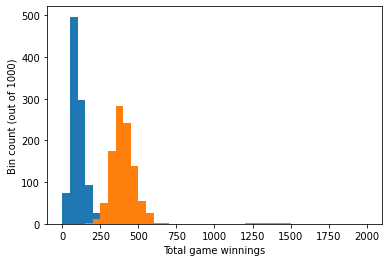

In [ ]:
#@title Plot score histograms
score_histogram(simple, name='simple')
score_histogram(optimal, name='optimal')

### Plenty of headroom

As you can see above, on a two-deck game the simple agents scores around 110 while optimal play can achieve around 450. Of course the optimal play agent cheats so we won't be able to achieve all that difference in reality, but it does indicate that we've got some room for improvement.

Note also that optimal scores are tri-modal: the bulk of shoes scoring around 400, but about one percent include a straight flush and score above 1000 and about half a percent include a royal flush and score above 10,000.

## Step 1: Computing probability of a winning hand

The first improvement is to iterate through all 32 possible ways to discard cards and compute the expected payout for each one. Essentially this is just counting all possible ways one could form each kind of hand. For example, if you start with holding 3♡A♣A♠, the number of ways to draw a full house is the number of ways to draw two threes plus the number of ways to draw a three and an ace. Dividing that by the number of unique ways to draw any two cards yields the probability. The actual implementation can get a little hairy since there are ten hand types and you need to be careful not to double-count, but that's the core idea. The implementation can be found in the poker_stats.py.

Note that the expected value calculated here isn't an estimate, it's an exact calculation of the expected value of the random payout associated with an action. The actual payout for a given action will vary depending on which cards come up next, but the expected value will be equal to the average payout across all possible orderings of the rest of the shoe.

After computing the expected payout for all 32 possible actions the agent simply takes the action with the maximum. We're still only taking the current hand's reward into account, but now we're at least being optimal with respect to that.



Total payout:   105


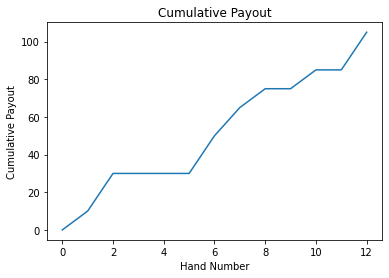

In [ ]:
#@title Run one game with PokerStats (current-hand probability) agent

# Use game from list for determinism
game = games[0].copy()  # Make copy so original is unmodified

# Main agent that actually makes the moves.
agent = player_agent.PokerStatsAgent(payout=payout, verbose=True, name='Stats')

# Play one game.
trajectory = player_agent.play_game(game, agent)

# Plot the cumulative payout.
payouts = np.array([move.payout for move in trajectory])
plt.plot(np.cumsum(payouts))

plt.xlabel('Hand Number')
plt.ylabel('Cumulative Payout')
_ = plt.title('Cumulative Payout')

print(f'Total payout:   {payouts.sum()}')


In [ ]:
#@title Hand details for above game
show_probability = True #@param {type:"boolean"}
show_payouts = True #@param {type:"boolean"}
start_hand = 9 #@param {type:"integer"}
end_hand = 9 #@param {type:"integer"}

from IPython import display

init_shoe_size = game.draw_shoe.num_decks * 52
num_discards = np.array([5 - m.held.size() for m in trajectory])
shoe_size = init_shoe_size - np.cumsum([5 + num_discards])

start_hand = max(0, start_hand)
end_hand = max(0, end_hand)

step = 1
if start_hand > end_hand:
  step = -1

for idx in range(start_hand, end_hand + step, step):
  move = trajectory[idx - 1]
  print(f'hand:  {idx} {move.initial_hand}')
  print(f'main:     {move.info[0]["value"]:.4f} ' +
        f'{move.held} -> {move.final_hand}')
  print(f'left in shoe: {shoe_size[idx]}')
  print(f'payout:       {move.payout}')
  cum_payout = payouts[:idx].sum()
  print(f'cumulative:   {cum_payout} / {payouts.sum()}')
  if show_probability:
    print('probabilities:')
    display.display(move.info[0]['probabilities'] * 100)
  if show_payouts:
    print('expected payouts:')
    pay = move.info[0]['probabilities'] * payout.table
    pay['total'] = pay.sum(axis=1)
    display.display(pay)
  print()

display.Javascript("google.colab.output.setIframeHeight('600px');")


hand:  9 [2♣5♠8♣J♣J♣]
main:     16.3158 [2♣8♣J♣J♣] -> [2♣5♢8♣J♣J♣]
left in shoe: 30
payout:       10
cumulative:   75 / 105
probabilities:


,royal,s. flush,5 kind,4 kind,f.house,flush,straight,3 kind,2 pair,j+ pair,low pair,no hand
,0.0,0.002789,0.000398,0.072518,0.198429,0.757458,0.386897,2.826621,5.005359,12.173717,30.414072,48.161740
2♣,0.0,0.000000,0.000000,0.014902,0.134119,0.001355,0.406421,1.987401,4.797128,7.961796,34.459121,50.237757
5♠,0.0,0.000000,0.001355,0.197792,0.438935,0.047416,0.495834,5.204904,7.013480,6.986385,40.060963,39.552936
8♣,0.0,0.000000,0.000000,0.062318,0.276367,0.001355,0.341394,3.362460,6.126126,7.456479,37.855449,44.518052
J♣,0.0,0.000000,0.000000,0.014902,0.134119,0.001355,0.260110,1.987401,4.798483,22.794825,19.624738,50.384068
J♣,0.0,0.000000,0.000000,0.014902,0.134119,0.001355,0.260110,1.987401,4.798483,22.794825,19.624738,50.384068
2♣5♠,0.0,0.000000,0.000000,0.047416,0.189663,0.000000,0.889047,2.939782,5.666193,4.267425,40.682788,45.317686
2♣8♣,0.0,0.000000,0.000000,0.011854,0.106686,0.047416,0.000000,1.884780,4.706022,4.421527,38.205311,50.616406
2♣J♣,0.0,0.000000,0.000000,0.000000,0.047416,0.047416,0.000000,1.137980,3.591750,16.500711,23.008535,55.666193
2♣J♣,0.0,0.000000,0.000000,0.000000,0.047416,0.047416,0.000000,1.137980,3.591750,16.500711,23.008535,55.666193


expected payouts:


,royal,s. flush,5 kind,4 kind,f.house,flush,straight,3 kind,2 pair,j+ pair,low pair,no hand,total
,0.0,0.027892,0.000797,0.058015,0.138901,0.454475,0.193449,0.565324,0.750804,1.217372,0.0,0.0,3.407027
2♣,0.0,0.000000,0.000000,0.011922,0.093883,0.000813,0.203211,0.397480,0.719569,0.796180,0.0,0.0,2.223058
5♠,0.0,0.000000,0.002709,0.158233,0.307255,0.028450,0.247917,1.040981,1.052022,0.698638,0.0,0.0,3.536205
8♣,0.0,0.000000,0.000000,0.049854,0.193457,0.000813,0.170697,0.672492,0.918919,0.745648,0.0,0.0,2.751880
J♣,0.0,0.000000,0.000000,0.011922,0.093883,0.000813,0.130055,0.397480,0.719772,2.279482,0.0,0.0,3.633408
J♣,0.0,0.000000,0.000000,0.011922,0.093883,0.000813,0.130055,0.397480,0.719772,2.279482,0.0,0.0,3.633408
2♣5♠,0.0,0.000000,0.000000,0.037933,0.132764,0.000000,0.444523,0.587956,0.849929,0.426743,0.0,0.0,2.479848
2♣8♣,0.0,0.000000,0.000000,0.009483,0.074680,0.028450,0.000000,0.376956,0.705903,0.442153,0.0,0.0,1.637624
2♣J♣,0.0,0.000000,0.000000,0.000000,0.033191,0.028450,0.000000,0.227596,0.538762,1.650071,0.0,0.0,2.478070
2♣J♣,0.0,0.000000,0.000000,0.000000,0.033191,0.028450,0.000000,0.227596,0.538762,1.650071,0.0,0.0,2.478070


<IPython.core.display.Javascript object>

In [ ]:
#@title Play multiple games using PokerStatsAgent
payouts_q = collections.deque()

for trial in notebook.trange(num_trials):
  game = games[trial].copy()
  agent = player_agent.PokerStatsAgent(payout=payout, verbose=False)
  _ = agent.play(game)
  payouts_q.append(game.score)
pstats = np.array(payouts_q)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
#@title Plot histogram of final scores
# score_histogram(poker_stats, name='one-hand probability')

NameError: ignored

## Step 2: Estimate additional advantage of holding

As mentioned earlier, in Countdown Poker the number of cards you hold in a hand will affect not just the payout for that hand but also the expected payout in subsequent hands. On each hand you can discard between zero and five cards, putting the next hand between five and ten cards further into the shoe than the last. Hands that are further into the shoe tend to have higher payouts because you have more knowledge of what cards remain, so holding fewer cards can be a good strategy in games with a hand limit. But in games with no hand limit it's generally advantageous to hold onto *more* cards than you normally might because that increases the number of hands you can play before the shoe is depleted.

It's not feasable to compute the exact expected reward across an entire game like we did for a single hand, so we're going to have to use sampling to estimate the value of a particular strategy. This falls into the area of [reinforcement learning](https://en.wikipedia.org/wiki/Reinforcement_learning), a subset of machine learning that deals with learning how to perform a task by playing through lots of examples and learning what leads to the highest rewards.

On any given turn an agent has access to an initial 5-card hand plus the contents (but not order) of the remaining shoe. In theory you could just bundle up these values into a state vector and train up a neural net using your favorite reinforcement-learning algorithm, but there are some significant headwinds to this approach. For a two-deck shoe there are around 10^29 possible input states (~3.7 million possible unique hands times 3^52 shoes) and 32 possible actions. That's large but not completely outside the realm of what modern RL techniques can handle, but the bigger issue is that the reward signal has a very high variance, which means we would need a *lot* of data to converge on anything useful.

Luckily, there is a better way.

### Recasting as a simpler game

A key insight is that while which cards are held back affects the expected reward on any given hand, only the *number* of cards held affects subsequent hands. For example, if my initial hand is 4♣10♣Q♣K♡A♣, I might try for a flush by discarding the King or try for an inside straight by discarding the Four. These would have different expected immediate reward but in either case my next hand would start one card further into the shoe than it is now, and all the cards in my hand plus the top card of the deck will be discarded regardless of my choice. (Note that my immediate reward and subsequent hands aren't independent — for example if I win with a straight it means there's one fewer Jack in the shoe for subsequent hands. But that Jack is going to come up next regardless of which cards I decide to hold.)

This means we can recast the problem as two separate games: one where you choose which cards to hold to maximize the reward of the current hand (32 possible actions), and one where you choose how *many* cards to hold to maximize the reward across the entire game (6 possible actions).

More formally, we want to compute the following functions:

* $R_e(H, S)$: expected reward (payout) when holding the set of cards $H$ and then drawing back up to five cards from shoe $S$, where $|H|$ is between zero and five.

* $R_e^*(D, S, h)$: expected reward when holding $h$ cards and discarding the rest given the five-card delt hand $D$. $R_e^*(D, S, h) = argmax [R_e(H, S), |H| = h]$. Expected rewards can also be written as a six-element vector by omitting the number held, i.e. $R_e(H, S)[h] = R_e(H, S, h)$.

* $c(H, S, h)$: the corresponding list of $h$ cards that should be held to maximize the expected payout.

* $A(S, \lambda, h)$: the expected _advantage_ 

* $H(S, R_e, \lambda)$: the number of cards to discard given contents of the shoe, expected reward, and number of hands remaining.

The goal of the first game is to maximize the payout of a single hand given the hand, shoe contents, and number of cards to hold. We've already solved this game, and can represent the optimal policy with the function $H$ representing which cards to hold and $R_e$ representing the corresponding expected reward. In the second game we're given the shoe contents, remaining number of hands, and value of $R_e(hand, shoe)$, with the goal of picking the number of cards to hold for each hand to maximize the total payout for the game.

## A new upper bound

Our previous upper bound was 



* $held(hand, shoe, h)$: the $h$ cards to hold to maximize expected reward given a hand and contents of the remaining shoe.
* $R_e(hand, shoe, h)$: expected reward (payout) when holding $held$ and discarding the rest. Expected rewards can also be written as a six-element vector by omitting the number held, so $R_e(hand, shoe)[h] = R_e(hand, shoe, h)$.
* $H(shoe, R_e, \lambda)$: the number of cards to discard given contents of the shoe, expected reward, and number of hands remaining.

This means we can split each hand into two separate parts. First we compute the expected reward for each of the 32 possible actions given both the current hand and shoe contents, and compute the maximum reward for each number of cards held along with which cards produce that reward. Then we estimate the relative advantage holding a number of cards will have towards our future rewards, not counting the immediate expected reward. The key is that this second estimate only needs to take into account the shoe contents and hand limit and not the hand itself, and the action space is only six elements (holding between zero and five cards) rather than thirty-two.

Here's a more explicit description:



In Reinforcement Learning there is the idea of an *Advantage*

 This is 





In games with no hand limit we would expect a slight advantage to holding more cards 

In [ ]:
#@title Play games with Limited Psychic Agent (optimal play maximizing expected)
payouts_q = collections.deque()

for trial in notebook.trange(num_trials):
  game = games[trial].copy()
  agent = player_agent.PsychicAgent(
      game.draw_shoe.cards, hand_limit=hand_limit, payout=payout, verbose=False,
      best_expected_only=True)
  _ = agent.play(game)
  payouts_q.append(game.score)
optimal_expected = np.array(payouts_q)

  0%|          | 0/1000 [00:00<?, ?it/s]

Mean winnings simple: 108.77 ± 19.68
Std winnings simple: 317.38
Min: 0, Max: 10035
% games with winnings >= 10000: 0.1

Percent games scoring < 1000:    98.5% (mean: 98.8 ± 2.9, std: 46.0)
Percent games scoring > 2000:     0.1% (mean: 10035.0 ± nan, std: 0.0)

Mean winnings one-hand probability: 143.36 ± 19.83
Std winnings one-hand probability: 319.85
Min: 10, Max: 10025
% games with winnings >= 10000: 0.1

Percent games scoring < 1000:    98.5% (mean: 132.3 ± 3.7, std: 59.7)
Percent games scoring 1000-2000:  0.1% (mean: 1135.0 ± nan, std: 0.0)
Percent games scoring > 2000:     0.1% (mean: 10025.0 ± nan, std: 0.0)

Mean winnings optimal_expected: 387.69 ± 44.05
Std winnings optimal_expected: 710.42
Min: 150, Max: 10405
% games with winnings >= 10000: 0.5

Percent games scoring < 1000:    98.5% (mean: 332.1 ± 4.4, std: 71.1)
Percent games scoring 1000-2000:  0.6% (mean: 1294.2 ± 59.7, std: 68.1)
Percent games scoring > 2000:     0.5% (mean: 10304.0 ± 63.2, std: 64.5)

Mean winnings opt

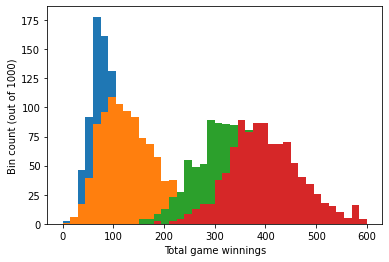

In [ ]:
#@title Plot score histograms
max_x = 600
score_histogram(simple, name='simple', max_x=max_x)
score_histogram(pstats, name='one-hand probability', max_x=max_x)
score_histogram(optimal_expected, name='optimal_expected', max_x=max_x)
score_histogram(optimal, name='optimal', max_x=max_x)


Mean winnings simple: 108.77 ± 19.68
Std winnings simple: 317.38
Min: 0, Max: 10035
% games with winnings >= 10000: 0.1

Percent games scoring < 1000:    98.5% (mean: 98.8 ± 2.9, std: 46.0)
Percent games scoring > 2000:     0.1% (mean: 10035.0 ± nan, std: 0.0)

Mean winnings optimal_expected: 387.69 ± 44.05
Std winnings optimal_expected: 710.42
Min: 150, Max: 10405
% games with winnings >= 10000: 0.5

Percent games scoring < 1000:    98.5% (mean: 332.1 ± 4.4, std: 71.1)
Percent games scoring 1000-2000:  0.6% (mean: 1294.2 ± 59.7, std: 68.1)
Percent games scoring > 2000:     0.5% (mean: 10304.0 ± 63.2, std: 64.5)

Mean winnings optimal: 456.99 ± 44.14
Std winnings optimal: 711.86
Min: 180, Max: 10440
% games with winnings >= 10000: 0.5

Percent games scoring < 1000:    98.5% (mean: 397.8 ± 4.5, std: 72.3)
Percent games scoring 1000-2000:  1.0% (mean: 1330.0 ± 49.4, std: 75.7)
Percent games scoring > 2000:     0.5% (mean: 10361.0 ± 49.5, std: 50.5)



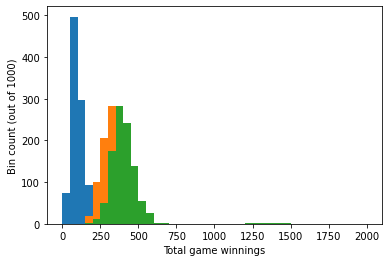

In [ ]:
#@title Plot score histograms
score_histogram(simple, name='simple')
#score_histogram(poker_stats, name='one-hand probability')
score_histogram(optimal_expected, name='optimal_expected')
score_histogram(optimal, name='optimal')


# Distributions

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.9/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


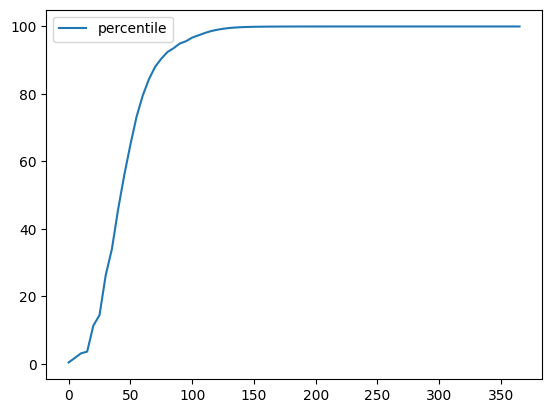

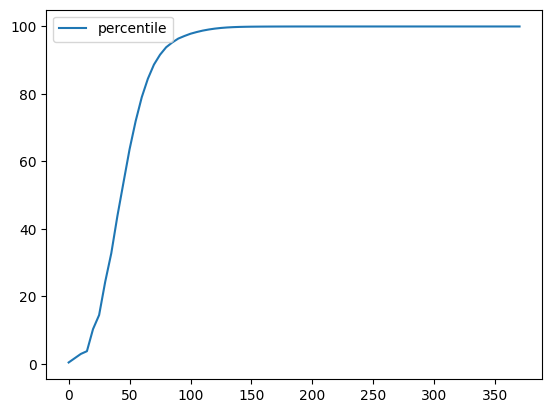

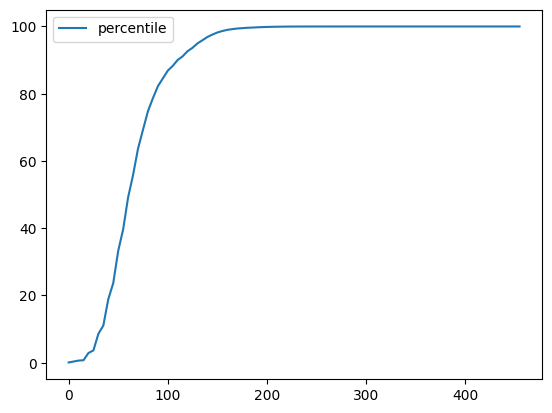

In [ ]:
import pandas as pd

from stats import shoe_stats

for g in range(3):
  game = games[g]
  dist_dict, _, _ = shoe_stats.calc_score_distribution(game.draw_shoe.cards, payout=game.payout)

  dist = pd.DataFrame(data=np.array([v for v in dist_dict.values()]) * 100,
                      index=dist_dict.keys(), columns=['percentile'])
  dist.plot()

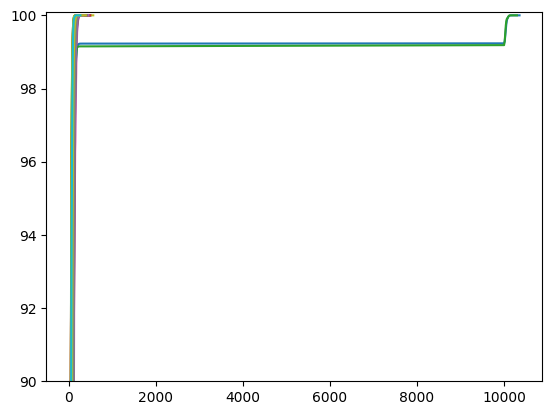

In [ ]:
from matplotlib import pyplot as plt

ax = None

for g in range(100):
  game = games[g]
  norm, dist, total = shoe_stats.calc_score_distribution(
      game.draw_shoe.cards, payout=game.payout)

  # keys = np.array([k for k in dist.keys()])
  # vals = np.array([v/total for v in dist.values()]) * 100

  keys = np.array([k for k in norm.keys()])
  pct = np.array([norm[k] for k in keys]) * 100

  dist = pd.DataFrame(data=pct, index=keys, columns=['percentile'])
  ax = dist.plot(ax=ax)

ax.set_ylim(90, 100.1)
ax.legend_.remove()

In [ ]:
keys

array([ 90,  95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150,
       155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215,
       220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280,
       285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345,
       350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410,
       415, 420])

/usr/local/lib/python3.9/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

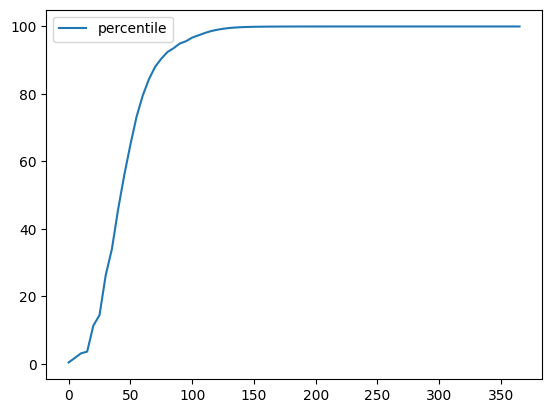

# Old/Scratch

In [ ]:
from game import payout_table
from agent import player_agent
from game import shoe

agent = player_agent.PokerStatsAgent(verbose=True)
draw_shoe = shoe.InteractiveShoe(num_decks=2)
payout = payout_table.PayoutTable.default()
game = poker_game.PokerGame(num_decks=2, draw_shoe=draw_shoe, payout=payout)
agent.play(game, verbose=True)



Draw 5 cards: KD KC 10H KC 6H
    held:  [K♣K♣K♢]
    value: 29.503195217480936
    hand:  [ 3.48398953  3.88875474 14.10012177 29.50319522 26.56565657 20.        ]
    adv:   [0. 0. 0. 0. 0. 0.]
    total: [ 3.48398953  3.88875474 14.10012177 29.50319522 26.56565657 20.        ]


KeyboardInterrupt: ignored

# PPO

In [ ]:
!pip install gym[box2d]

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 50.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 KB 31.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for box2d-py
  Running setup.py clean for box2d-py
Failed to build box2d-py
  Running setup.py install for box2d-py ... done
  DEPRECATION: box2d-py was installed using the legacy 'setup.py install' method, because a wheel could not be built for it. A possible replacement is to fix the wheel build issue reported above. Discussion can be found at https:

In [ ]:
import gym

# Create the environment
env = gym.make('LunarLander-v2')  # continuous: LunarLanderContinuous-v2

# required before you can step the environment
env.reset()

# sample action:
print("sample action:", env.action_space.sample())

# observation space shape:
print("observation space shape:", env.observation_space.shape)

# sample observation:
print("sample observation:", env.observation_space.sample())

env.close()

DependencyNotInstalled: ignored

payout table: rf: 10000, sf: 1000, 5k: 200, 4k: 80, fh: 70, fl: 60, st: 50, 3k: 20, 2p: 15, j+: 10, 1p: 0, ante: 0
baseline total payout:   145
DQN total payout:   285


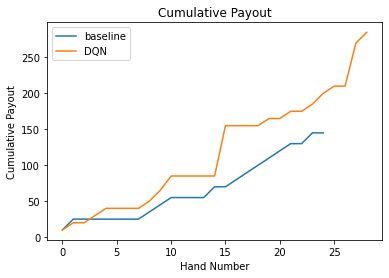

In [ ]:

num_decks = 4 #@param ["2", "4"] {type:"raw"}
payout = payout_table.PayoutTable.default()
hand_limit = 0

game = poker_game.PokerGame(num_decks=num_decks, payout=payout,
                            hand_limit=hand_limit)

# Agent that plays to optimize current hand payout
agent_base = player_agent.PokerStatsAgent(verbose=True, name='baseline')
agent_dqn = player_agent.DQNAgent('checkpoints/dqn.pt',
                                  verbose=True, name='DQN')
agents = (agent_base, agent_dqn)

def play(agent, game):
  agent.play(game)
  payouts = np.array([move.payout for move in game.history])
  plt.plot(np.cumsum(payouts))
  print(f'{agent.name} total payout:   {payouts.sum()}')

for agent in agents:
  play(agent, copy.deepcopy(game))

plt.xlabel('Hand Number')
plt.ylabel('Cumulative Payout')
plt.legend([agent.name for agent in agents])
_ = plt.title('Cumulative Payout')


In [ ]:
num_decks = 4 #@param ["2", "4"] {type:"raw"}
num_trials = 100 #@param {type:"integer"}

payout = payout_table.PayoutTable.default()
hand_limit = 0

# Agent that plays to optimize current hand payout
agent_base = player_agent.PokerStatsAgent(verbose=True, name='baseline')
agent_dqn = player_agent.DQNAgent('checkpoints/dqn.pt',
                                  verbose=True, name='DQN')

def play(agent, game):
  agent.play(game)
  return game.score

scores = np.full((num_trials, 2), np.nan)

for trial in notebook.trange(num_trials):
  game = poker_game.PokerGame(num_decks=num_decks, payout=payout,
                              hand_limit=hand_limit)
  scores[trial, 0] = play(agent_base, copy.deepcopy(game))
  scores[trial, 1] = play(agent_dqn, game)


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
scores.mean(axis=0)

array([403.  , 308.45])

In [ ]:
from scipy import special

print(special.softmax([1, 2]))
print(special.softmax([2, 4]))
print(special.softmax([3, 6]))


[0.26894142 0.73105858]
[0.11920292 0.88079708]
[0.04742587 0.95257413]


# Compute target scores



Play shoes using agents of various skill levels and record the score they get. We currently have three agents. These roughly correspond to *good*, *better* and *best*, but because the first two agents work with incomplete knowledge the *hand* score will sometimes be higher than the *card_count* score for a given shoe. You'll probably want to pick just one of the first two numbers to use as "par" in your summary screen and ignore the other.

* **hand:** maximizes expected payout for each hand based only on the current hand (and number of decks being played), but not which cards are still in the shoe.
* **card_count:** maximizes expected payout for each hand based on both the current hand and cards remaining in the shoe, but not the order of those cards.
* **psychic:** optimal play given complete knowledge, including card order in the shoe. This is the maximum possible score for a shoe.

## Instructions

1. Load [Over/Under](https://fireopalmedia.com/j/Json/), and note the current seed in the bottom-left corner.
1. Exit out to front page
1. Alternate clicking between bars and "Over" until build # turns red
1. Type in the seed and deckcount in the fields at the bottom.
1. Click custom to enter the game. This will put shoe contents for that seed and the next 100 seeds into clipboard in JSON format.
1. Load this page and paste the clipboard contents into the 'json_input' field below.
1. Check whether you want to use the proposed higher payouts (flush=6 and straight=5) or the current table, and pick a hand limit (zero for unlimited).
1. Execute the 'Clone GitHub repo' cell above and then the 'Compute target scores' cell.
1. Copy the resulting JSON code to clipboard.

It typically takes about five minutes to compute targets for 100 four-deck shoes.

## Input format

Shoes are specified in the JSON format produced by the Over/Under implementation (Build 0.6.17 and later), and have the following format:

    [{seed: <int>, deck:[{rank: <int>, suit: <int>}, ...]},
     {seed: <int>, deck:[{rank: <int>, suit: <int>}, ...]},
     ...]

Ace is represented as rank 14, and *suit* will be one of (1, 4, 8, 16), which corresponds to spades, clubs, hearts and diamonds respectively.

## Output format

Output will be a JSON string formatted as:

    [{"seed": <int>, "num_decks": <int>, "hand": <int>, "card_count": <int>, "psychic": <int>},
     {"seed": <int>, "num_decks": <int>, "hand": <int>, "card_count": <int>, "psychic": <int>},    
      ...]


In [ ]:
#@title Compute target scores
json_input = "[{\"seed\":752596,\"deck\":[{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":1}]},{\"seed\":752597,\"deck\":[{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":16}]},{\"seed\":752598,\"deck\":[{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":1}]},{\"seed\":752599,\"deck\":[{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":1}]},{\"seed\":752600,\"deck\":[{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":4}]},{\"seed\":752601,\"deck\":[{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":1}]},{\"seed\":752602,\"deck\":[{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":16}]},{\"seed\":752603,\"deck\":[{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":1}]},{\"seed\":752604,\"deck\":[{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":1}]},{\"seed\":752605,\"deck\":[{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":4}]},{\"seed\":752606,\"deck\":[{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":1}]},{\"seed\":752607,\"deck\":[{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":4}]},{\"seed\":752608,\"deck\":[{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":8}]},{\"seed\":752609,\"deck\":[{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":4}]},{\"seed\":752610,\"deck\":[{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":8}]},{\"seed\":752611,\"deck\":[{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4}]},{\"seed\":752612,\"deck\":[{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8}]},{\"seed\":752613,\"deck\":[{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":8}]},{\"seed\":752614,\"deck\":[{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":1}]},{\"seed\":752615,\"deck\":[{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8}]},{\"seed\":752616,\"deck\":[{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":8}]},{\"seed\":752617,\"deck\":[{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4}]},{\"seed\":752618,\"deck\":[{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":8}]},{\"seed\":752619,\"deck\":[{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1}]},{\"seed\":752620,\"deck\":[{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4}]},{\"seed\":752621,\"deck\":[{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16}]},{\"seed\":752622,\"deck\":[{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":4}]},{\"seed\":752623,\"deck\":[{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4}]},{\"seed\":752624,\"deck\":[{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":4}]},{\"seed\":752625,\"deck\":[{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":8}]},{\"seed\":752626,\"deck\":[{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":8}]},{\"seed\":752627,\"deck\":[{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":1}]},{\"seed\":752628,\"deck\":[{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":1}]},{\"seed\":752629,\"deck\":[{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":16}]},{\"seed\":752630,\"deck\":[{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":1}]},{\"seed\":752631,\"deck\":[{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":8}]},{\"seed\":752632,\"deck\":[{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":16}]},{\"seed\":752633,\"deck\":[{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4}]},{\"seed\":752634,\"deck\":[{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":16}]},{\"seed\":752635,\"deck\":[{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16}]},{\"seed\":752636,\"deck\":[{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":8}]},{\"seed\":752637,\"deck\":[{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":16}]},{\"seed\":752638,\"deck\":[{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":4}]},{\"seed\":752639,\"deck\":[{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":4}]},{\"seed\":752640,\"deck\":[{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":16}]},{\"seed\":752641,\"deck\":[{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":1}]},{\"seed\":752642,\"deck\":[{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1}]},{\"seed\":752643,\"deck\":[{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":8}]},{\"seed\":752644,\"deck\":[{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":16}]},{\"seed\":752645,\"deck\":[{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":4}]},{\"seed\":752646,\"deck\":[{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":1}]},{\"seed\":752647,\"deck\":[{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16}]},{\"seed\":752648,\"deck\":[{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4}]},{\"seed\":752649,\"deck\":[{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4}]},{\"seed\":752650,\"deck\":[{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":1}]},{\"seed\":752651,\"deck\":[{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":4}]},{\"seed\":752652,\"deck\":[{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":16}]},{\"seed\":752653,\"deck\":[{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":8}]},{\"seed\":752654,\"deck\":[{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16}]},{\"seed\":752655,\"deck\":[{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":8}]},{\"seed\":752656,\"deck\":[{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":16}]},{\"seed\":752657,\"deck\":[{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":16}]},{\"seed\":752658,\"deck\":[{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":16}]},{\"seed\":752659,\"deck\":[{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":1}]},{\"seed\":752660,\"deck\":[{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4}]},{\"seed\":752661,\"deck\":[{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":8}]},{\"seed\":752662,\"deck\":[{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":16}]},{\"seed\":752663,\"deck\":[{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":4}]},{\"seed\":752664,\"deck\":[{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":8}]},{\"seed\":752665,\"deck\":[{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":8}]},{\"seed\":752666,\"deck\":[{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":8}]},{\"seed\":752667,\"deck\":[{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1}]},{\"seed\":752668,\"deck\":[{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4}]},{\"seed\":752669,\"deck\":[{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":16}]},{\"seed\":752670,\"deck\":[{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":1}]},{\"seed\":752671,\"deck\":[{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":8}]},{\"seed\":752672,\"deck\":[{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":4}]},{\"seed\":752673,\"deck\":[{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":4}]},{\"seed\":752674,\"deck\":[{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":1}]},{\"seed\":752675,\"deck\":[{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":1}]},{\"seed\":752676,\"deck\":[{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1}]},{\"seed\":752677,\"deck\":[{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":8}]},{\"seed\":752678,\"deck\":[{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1}]},{\"seed\":752679,\"deck\":[{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":1}]},{\"seed\":752680,\"deck\":[{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16}]},{\"seed\":752681,\"deck\":[{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16}]},{\"seed\":752682,\"deck\":[{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":4}]},{\"seed\":752683,\"deck\":[{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":2,\"suit\":1}]},{\"seed\":752684,\"deck\":[{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":8}]},{\"seed\":752685,\"deck\":[{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":8}]},{\"seed\":752686,\"deck\":[{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":1}]},{\"seed\":752687,\"deck\":[{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":9,\"suit\":1}]},{\"seed\":752688,\"deck\":[{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":1}]},{\"seed\":752689,\"deck\":[{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8}]},{\"seed\":752690,\"deck\":[{\"rank\":5,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":8}]},{\"seed\":752691,\"deck\":[{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":10,\"suit\":1},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":4,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":13,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":8,\"suit\":16}]},{\"seed\":752692,\"deck\":[{\"rank\":10,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":9,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":12,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":4,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":1},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":5,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":2,\"suit\":16},{\"rank\":3,\"suit\":4}]},{\"seed\":752693,\"deck\":[{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":9,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":10,\"suit\":4},{\"rank\":10,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":3,\"suit\":4},{\"rank\":11,\"suit\":8},{\"rank\":13,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":13,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":14,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":4,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":14,\"suit\":4},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":11,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":7,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":2,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":5,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":16},{\"rank\":2,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":4}]},{\"seed\":752694,\"deck\":[{\"rank\":2,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":8,\"suit\":16},{\"rank\":12,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":11,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":7,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":16},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":14,\"suit\":8},{\"rank\":4,\"suit\":16},{\"rank\":13,\"suit\":4},{\"rank\":9,\"suit\":8},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":3,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":8,\"suit\":4},{\"rank\":9,\"suit\":1},{\"rank\":7,\"suit\":8},{\"rank\":11,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":7,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":4,\"suit\":4},{\"rank\":6,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":14,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":6,\"suit\":8},{\"rank\":2,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":16},{\"rank\":4,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":2,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":3,\"suit\":16},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":10,\"suit\":1},{\"rank\":13,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":9,\"suit\":4},{\"rank\":8,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":12,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":10,\"suit\":16},{\"rank\":13,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":8},{\"rank\":5,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":13,\"suit\":1},{\"rank\":6,\"suit\":4},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":10,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":1},{\"rank\":12,\"suit\":8},{\"rank\":14,\"suit\":8},{\"rank\":13,\"suit\":16}]},{\"seed\":752695,\"deck\":[{\"rank\":4,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":6,\"suit\":1},{\"rank\":13,\"suit\":8},{\"rank\":6,\"suit\":16},{\"rank\":13,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":7,\"suit\":16},{\"rank\":7,\"suit\":8},{\"rank\":8,\"suit\":8},{\"rank\":10,\"suit\":4},{\"rank\":4,\"suit\":8},{\"rank\":2,\"suit\":1},{\"rank\":2,\"suit\":4},{\"rank\":7,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":7,\"suit\":4},{\"rank\":13,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":11,\"suit\":16},{\"rank\":3,\"suit\":4},{\"rank\":2,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":8,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":6,\"suit\":16},{\"rank\":2,\"suit\":4},{\"rank\":4,\"suit\":16},{\"rank\":11,\"suit\":1},{\"rank\":11,\"suit\":1},{\"rank\":13,\"suit\":1},{\"rank\":14,\"suit\":8},{\"rank\":7,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":11,\"suit\":4},{\"rank\":7,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":16},{\"rank\":8,\"suit\":4},{\"rank\":3,\"suit\":16},{\"rank\":6,\"suit\":1},{\"rank\":9,\"suit\":8},{\"rank\":8,\"suit\":1},{\"rank\":2,\"suit\":8},{\"rank\":12,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":2,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":12,\"suit\":1},{\"rank\":10,\"suit\":8},{\"rank\":11,\"suit\":8},{\"rank\":11,\"suit\":16},{\"rank\":13,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":5,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":9,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":12,\"suit\":4},{\"rank\":10,\"suit\":16},{\"rank\":10,\"suit\":4},{\"rank\":7,\"suit\":8},{\"rank\":5,\"suit\":1},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":9,\"suit\":16},{\"rank\":5,\"suit\":16},{\"rank\":14,\"suit\":4},{\"rank\":2,\"suit\":16},{\"rank\":11,\"suit\":8},{\"rank\":14,\"suit\":16},{\"rank\":12,\"suit\":8},{\"rank\":13,\"suit\":4},{\"rank\":12,\"suit\":16},{\"rank\":3,\"suit\":1},{\"rank\":13,\"suit\":4},{\"rank\":5,\"suit\":4},{\"rank\":3,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":6,\"suit\":8},{\"rank\":10,\"suit\":8},{\"rank\":8,\"suit\":4},{\"rank\":14,\"suit\":8},{\"rank\":6,\"suit\":8},{\"rank\":4,\"suit\":4},{\"rank\":5,\"suit\":1},{\"rank\":12,\"suit\":1},{\"rank\":8,\"suit\":8},{\"rank\":4,\"suit\":1},{\"rank\":3,\"suit\":8},{\"rank\":9,\"suit\":1},{\"rank\":9,\"suit\":4},{\"rank\":3,\"suit\":8},{\"rank\":6,\"suit\":4},{\"rank\":11,\"suit\":4},{\"rank\":14,\"suit\":1},{\"rank\":10,\"suit\":1},{\"rank\":10,\"suit\":16},{\"rank\":4,\"suit\":16},{\"rank\":5,\"suit\":4},{\"rank\":5,\"suit\":8},{\"rank\":4,\"suit\":8}]}]" #@param {type:"string"}
higher_payouts = True #@param {type:"boolean"}
hand_limit = 0 #@param {type:"integer"}


from tqdm import notebook
import json

from stats import shoe_stats
from game import payout_table

if higher_payouts:
  target_payout = payout_table.PayoutTable(
    royal_flush=1000,
    straight_flush=100,
    five_kind=20,
    four_kind=8,
    full_house=7,
    flush=6,
    straight=5,
    three_kind=2,
    two_pair=1,
    jack_high_pair=1,
    low_pair=0,
    ante=0)
else:
  target_payout = payout_table.PayoutTable(
    royal_flush=1000,
    straight_flush=100,
    five_kind=20,
    four_kind=8,
    full_house=7,
    flush=5,
    straight=4,
    three_kind=2,
    two_pair=1,
    jack_high_pair=1,
    low_pair=0,
    ante=0)

json_data = json.loads(json_input)
scores = [shoe_stats.analyze_json_data(shoe_data, target_payout, hand_limit)
          for shoe_data in notebook.tqdm(json_data)]
scores_json = shoe_stats.scores_to_json_str(scores)
print(scores_json)

  0%|          | 0/100 [00:00<?, ?it/s]

[{"seed": 752596, "num_decks": 2, "hand": 6, "card_count": 20, "psychic": 42}, {"seed": 752597, "num_decks": 2, "hand": 15, "card_count": 15, "psychic": 27}, {"seed": 752598, "num_decks": 2, "hand": 18, "card_count": 16, "psychic": 42}, {"seed": 752599, "num_decks": 2, "hand": 10, "card_count": 19, "psychic": 39}, {"seed": 752600, "num_decks": 2, "hand": 9, "card_count": 14, "psychic": 53}, {"seed": 752601, "num_decks": 2, "hand": 4, "card_count": 14, "psychic": 27}, {"seed": 752602, "num_decks": 2, "hand": 11, "card_count": 13, "psychic": 39}, {"seed": 752603, "num_decks": 2, "hand": 5, "card_count": 7, "psychic": 26}, {"seed": 752604, "num_decks": 2, "hand": 16, "card_count": 16, "psychic": 50}, {"seed": 752605, "num_decks": 2, "hand": 17, "card_count": 15, "psychic": 46}, {"seed": 752606, "num_decks": 2, "hand": 15, "card_count": 21, "psychic": 43}, {"seed": 752607, "num_decks": 2, "hand": 11, "card_count": 20, "psychic": 33}, {"seed": 752608, "num_decks": 2, "hand": 9, "card_count"

In [ ]:
#@title Setup

num_decks = 4 #@param ["1", "2", "3", "4", "5", "6"] {type:"raw"}
hand_limit = 0 #@param {type:"integer"}

royal_flush = 10000 #@param {type:"integer"}
straight_flush = 1000 #@param {type:"integer"}
five_kind = 200 #@param {type:"integer"}
four_kind = 80 #@param {type:"integer"}
full_house = 70 #@param {type:"integer"}
flush = 60 #@param {type:"integer"}
straight = 50 #@param {type:"integer"}
three_kind = 20 #@param {type:"integer"}
two_pair = 10 #@param {type:"integer"}
jack_high_pair = 5 #@param {type:"integer"}
low_pair = 5 #@param {type:"integer"}
ante = 0 #@param {type:"integer"}

import copy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from game import payout_table
from agent import player_agent
from game import poker_game

payout = payout_table.PayoutTable(
    royal_flush, straight_flush, five_kind, four_kind, full_house, flush,
    straight, three_kind, two_pair, jack_high_pair, low_pair, ante=ante)

# Psycic diffs

In [ ]:
#@title Run trials

num_trials = 10000 #@param {type:"integer"}
num_decks = 4 #@param {type:"integer"}
hand_limit = 0 #@param {type:"integer"}
payout = None

from scipy import stats
from tqdm import notebook

from game import psychic_solver
from game import poker_stats

from tqdm.notebook import trange

shoe_size = num_decks * 52
optimal = np.full((num_trials, shoe_size - 9), np.nan)
for trial in trange(num_trials):
  game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
  psy = psychic_solver.PsychicSolver(
          game.draw_shoe.cards, game.hand_limit, payout)
  #optimal[trial, :] = psy.solve()
  optimal[trial, :] = psy.solve_all()[0]


  0%|          | 0/10000 [00:00<?, ?it/s]

[-11.3251627   -6.82331878  -2.30508598   2.24033995   6.81344841
  11.3997791 ]
[-11.19421667  -6.72377667  -2.25039667   2.25520333   6.74064333
  11.17254333]
[-11.55936667  -6.93074667  -2.31486667   2.32519333   6.93259333
  11.54719333]
[-11.12241333  -6.64965333  -2.22631333   2.18256667   6.67012667
  11.14568667]
[-11.12387333  -6.89445333  -2.54813333   2.00884667   6.79094667
  11.76666667]


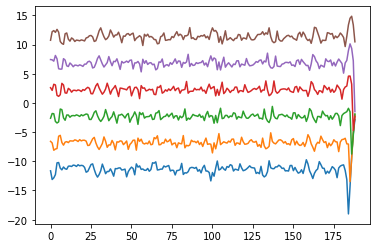

In [ ]:
diffs = np.lib.stride_tricks.sliding_window_view(optimal, window_shape=6, axis=1).copy()
normed = (diffs - diffs.mean(axis=-1, keepdims=True)).mean(axis=0)[5:, ::-1]
_ = plt.plot(normed)

print(normed.mean(axis=0))
print(normed[0:25].mean(axis=0))
print(normed[25:50].mean(axis=0))
print(normed[50:75].mean(axis=0))
print(normed[-25:].mean(axis=0))


array([-11.53682981,  -6.98936949,  -2.3615388 ,   2.28735009,
         6.95481041,  11.6455776 ])

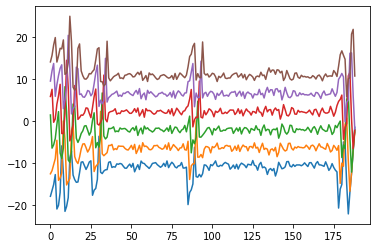

In [ ]:
diffs = np.lib.stride_tricks.sliding_window_view(optimal, window_shape=6, axis=1).copy()
normed = (diffs - diffs.mean(axis=-1, keepdims=True)).mean(axis=0)[5:, ::-1]
_ = plt.plot(normed)

normed.mean(axis=0)


In [ ]:
np.array([1,2,3]) + [10, 20, 30]

array([11, 22, 33])

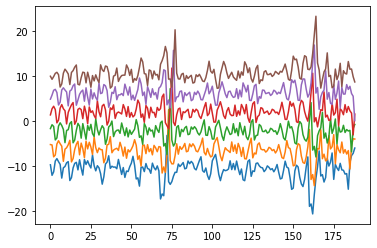

In [ ]:
diffs = np.lib.stride_tricks.sliding_window_view(optimal, window_shape=6, axis=1).copy()
normed = (diffs - diffs.mean(axis=-1, keepdims=True)).mean(axis=0)[5:, ::-1]
_ = plt.plot(normed)




# Single-hand analysis

Experiment:
1. Generate random shoes at varying levels of depletion.
1. Using PokerStats, compute:
  1. Optimal number of cards to hold and expected winnings.
  1. Difference between expected winnings for each number of cards held (0-5).

Predictions:
* Expected winnings go up as shoe size goes down.
* 



# Payout calibration for straight

**Problem:** People don't go for straights with the current payout table.

**Experiment:** Sweep through different straight values and shoe sizes, keeping the rest of the payout table the same. Track at what level it becomes worthwhile to try for:
* inside straight (2-4-5-6, hoping for 3)
* outside straight (2-3-4-5, hoping for A or 6)
* 2-slot outside straight (3-4-5 hoping for A-2, 2-6 or 6-7)

**Results:**

* Outside straight is already favored most of the time at payout of 4.
* Inside straight reaches 50% favorable at payout of 6.
* Two-slot straight doesn't reach 50% favorable until about 10.

Other insights:
* Straights become less favorable compared to other hands as the shoe gets smaller, since there are usually fewer ways to complete a straight than n-of-a-kind.
* There's not *that* much difference between two and four decks.
* For really small shoes there's no reward that will encourage straights in all cases, because there are some combinations where the card(s) you need are already depleted.
* Straight and flush don't compete much, so these results probably won't change if you also bump the flush payment to keep them in traditional poker-hand order.

In [ ]:
#@title Setup
import random
from tqdm import notebook

import pandas as pd

from game import card
from game import hand
from game import shoe
from game import poker_stats
from game import payout_table


def pct_hands_trying_for_straight(
    init_hand: str, target_held_str: str,
    num_trials: int = 100, num_decks: int = 4,
    min_payout: int = 40, max_payout: int = 100):
  delt = hand.Hand(init_hand)
  target_held = hand.Hand(target_held_str)  
  card_list = shoe.Shoe.shoe_excluding_cards(
    delt.cards, num_decks=num_decks).cards
  shoe_sizes = np.linspace(5, len(card_list), 5).astype(int)
  straight_values = np.arange(min_payout, max_payout+1, 10)
  out = pd.DataFrame(data=0, index=straight_values, columns=shoe_sizes)

  for trial in notebook.trange(num_trials):
    for shoe_size in shoe_sizes:
      random.shuffle(card_list)
      for straight_value in straight_values:
        payout_t = payout_table.PayoutTable(
            10000, 1000, 200, 80, 70, 60, straight_value, 20, 10, 5, 5, ante=0)
        ps = poker_stats.PokerStats(card_list[:shoe_size], payout=payout_t)
        hv = ps.best_expected_payout(delt)
        if hv.held == target_held:
          out.loc[straight_value, shoe_size] += 1
          break
  return 100 * out.cumsum(axis=0) / num_trials

def plot_pct_hands(data, desc, num_decks, ax=None):
  data.plot(ax=ax, grid=True)
  ax.set_xlabel('Payout for straight')
  ax.set_ylabel('% try straight')
  ax.set_title(f'{desc} ({num_decks} decks)')  

In [ ]:
#@title Run trials
num_trials = 100 #@param {type:"integer"}

inside4 = pct_hands_trying_for_straight(
    '2C 4D 5H 6S KC', '2C 4D 5H 6S', num_trials, num_decks=4)
inside2 = pct_hands_trying_for_straight(
    '2C 4D 5H 6S KC', '2C 4D 5H 6S', num_trials, num_decks=2)

outside4 = pct_hands_trying_for_straight(
    '2C 3D 4D 5H KC', '2C 3D 4D 5H', num_trials, num_decks=4)
outside2 = pct_hands_trying_for_straight(
    '2C 3D 4D 5H KC', '2C 3D 4D 5H', num_trials, num_decks=2)

twoslot_4 = pct_hands_trying_for_straight(
    '3D 4D 5H 9H KC', '3D 4D 5H', num_trials, num_decks=4,
    min_payout=40, max_payout=150)
twoslot_2 = pct_hands_trying_for_straight(
    '3D 4D 5H 9H KC', '3D 4D 5H', num_trials, num_decks=2,
    min_payout=40, max_payout=150)

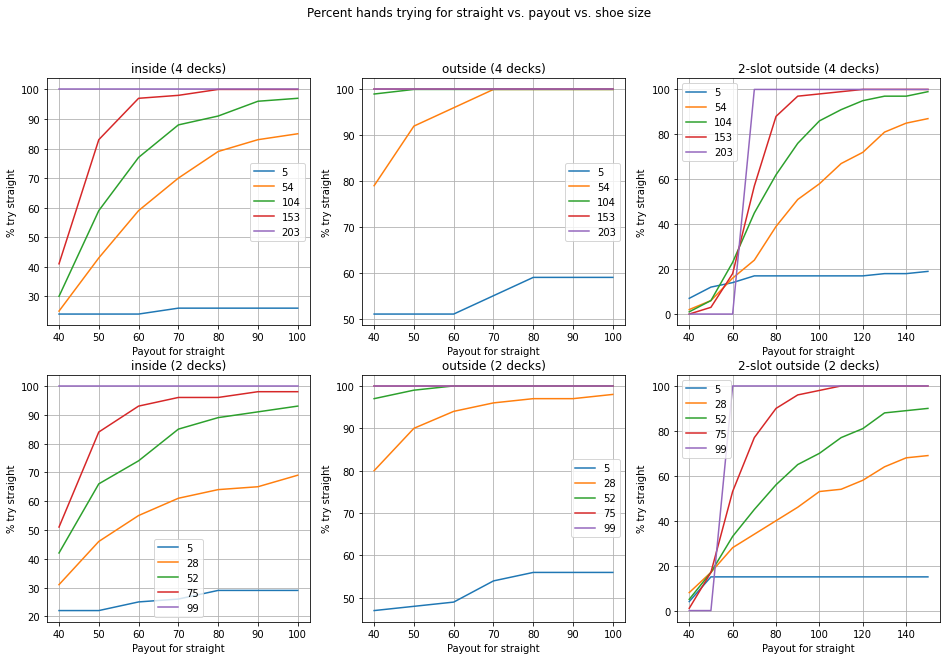

In [ ]:
#@title Plot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
plot_pct_hands(inside4, desc='inside',
               num_decks=4, ax=axes[0][0])
plot_pct_hands(outside4, desc='outside',
               num_decks=4, ax=axes[0][1])
plot_pct_hands(twoslot_4, desc='2-slot outside',
               num_decks=4, ax=axes[0][2])

plot_pct_hands(inside2, desc='inside',
               num_decks=2, ax=axes[1][0])
plot_pct_hands(outside2, desc='outside',
               num_decks=2, ax=axes[1][1])
plot_pct_hands(twoslot_2, desc='2-slot outside',
               num_decks=2, ax=axes[1][2])

_ = fig.suptitle(
    'Percent hands trying for straight vs. payout vs. shoe size')

In [ ]:
#@title Expected payout vs. shoe size
num_trials = 100 #@param {type:"integer"}
num_decks = 4 #@param {type:"integer"}


import collections
from tqdm import notebook

from game import hand
from game import shoe
from game import poker_stats


max_shoe_size = num_decks * 52
base = 10
num_cards_a = ((np.logspace(0, 1, base=base, endpoint=True, num=10) - 1) /
               (base-1) * (max_shoe_size - 10) + 10).astype(int)
expected_winnings = np.zeros((num_trials, num_cards_a.shape[0], 6))

for trial in notebook.trange(num_trials):
  for idx in range(num_cards_a.shape[0]):
    num_cards = num_cards_a[idx]
    draw_shoe = shoe.Shoe.shoe_with_num_cards_remaining(
        num_cards, num_decks=num_decks)
    delt = hand.Hand(draw_shoe.draw_cards())
    ps = poker_stats.PokerStats(draw_shoe.cards, payout=payout)
    hvs = ps.best_expected_payout_per_num_held(delt)
    expected_winnings[trial, idx, :] = [hv.value for hv in hvs]


  0%|          | 0/100 [00:00<?, ?it/s]

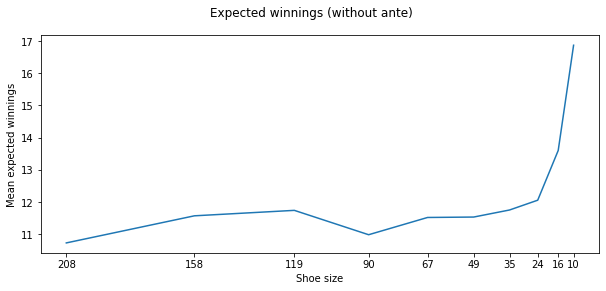

In [ ]:
#@title Plot
ew_mean = expected_winnings.max(axis=-1).mean(axis=0)
num_held_mean = expected_winnings.argmax(axis=-1).mean(axis=0)

fig, ax = plt.subplots(figsize=(10,4))
if ante:
  fig.suptitle('Expected winnings (with ante)')
else:
  fig.suptitle('Expected winnings (without ante)')

ax.plot(num_cards_a, ew_mean)
ax.set_xticks(num_cards_a)
ax.invert_xaxis()
ax.set_xlabel('Shoe size')
_ = ax.set_ylabel('Mean expected winnings')


min: 0.0, max: 154.0


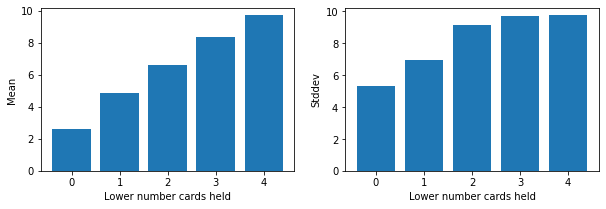

In [ ]:
#@title Plot difference between best num_held and each other num_held, in order
ordered = np.sort(expected_winnings, axis=-1)[:, :, ::-1]
diffs = ordered[:, :, 0:1] - ordered[:, :, 1:]
diffs_mean = diffs.mean(axis=0).mean(axis=0)
diffs_std = diffs.std(axis=(0,1))


fig, axes = plt.subplots(figsize=(10, 3), ncols=2)
axes[0].bar(np.arange(5), diffs_mean)
axes[1].bar(np.arange(5), diffs_std)
for ax in axes:
  ax.set_xlabel('Lower number cards held')
axes[0].set_ylabel('Mean')
_ = axes[1].set_ylabel('Stddev')

print(f'min: {diffs.min()}, max: {diffs.max()}')



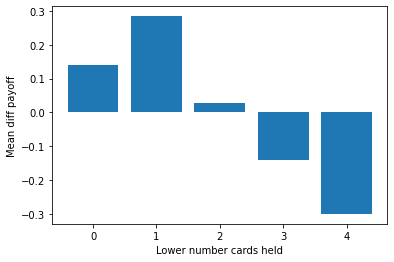

In [ ]:
#@title Plot diff between expected winnings for each num held

diffs = np.diff(expected_winnings, axis=-1).mean(axis=0).mean(axis=0)
plt.bar(np.arange(5), diffs)
plt.xlabel('Lower number cards held')
_ = plt.ylabel('Mean diff payoff')



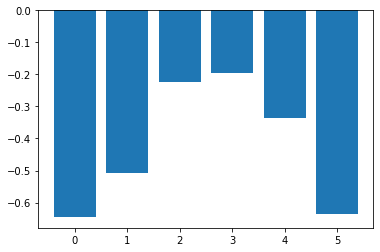

In [ ]:
_ = plt.bar(np.arange(6), expected_winnings.mean(axis=0).mean(axis=0))

# Single-game analysis

Total payout:   700
Game score: 700
Mean cards held: 2.8214285714285716
Hands played: 28
held_list: 28


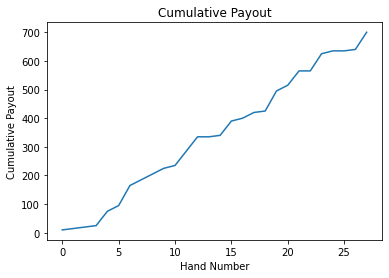

In [ ]:
#@title Run one game with PsychicAgent
game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
gc = copy.deepcopy(game)

# Agent that evaluates based on optimal play (it cheats).
agent_opt = player_agent.PsychicAgent(game, verbose=True, name='psychic')

# Play one game.
trajectory = player_agent.play_game(game, [agent_opt])

# Plot the cumulative payout.
payouts = np.array([move.payout for move in trajectory])
plt.plot(np.cumsum(payouts))

plt.xlabel('Hand Number')
plt.ylabel('Cumulative Payout')
_ = plt.title('Cumulative Payout')

print(f'Total payout:   {payouts.sum()}')
print(f'Game score: {game.score}')
num_held = np.array([gm.held.size() for gm in trajectory])
print(f'Mean cards held: {num_held.mean()}')
print(f'Hands played: {len(trajectory)}')




Total payout:   185
Optimal payout: 10.0


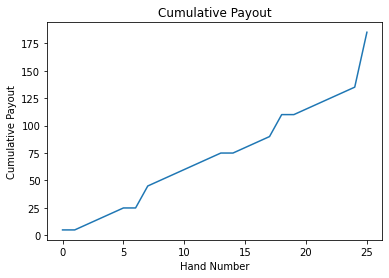

In [ ]:
#@title Run one game with PokerStats (single-hand probability) agent
game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)

# Main agent that actually makes the moves.
agent = player_agent.PokerStatsAgent(game, verbose=True, name='main')

# Agent that evaluates based on n-of-a-kind hands only.
payout_nkind = payout_table.PayoutTable(
    0, 0, five_kind, four_kind, 0, flush, 0,
    three_kind, two_pair, jack_high_pair, low_pair, ante=ante)
agent_nkind = player_agent.PokerStatsAgent(
    game, payout=payout_nkind, verbose=True, name='nkind')

# Agent that evaluates based on straight-type hands only.
payout_straight = payout_table.PayoutTable(
    royal_flush, straight_flush, 0, 0, 0, 0, straight,
    0, 0, 0, 0, ante=ante)
agent_straight = player_agent.PokerStatsAgent(
    game, payout=payout_straight, verbose=True, name='straight')

# Agent that evaluates based on optimal play (it cheats).
agent_opt = player_agent.PsychicAgent(game, verbose=True, name='psychic')

# Play one game.
trajectory = player_agent.play_game(
    game, [agent, agent_nkind, agent_straight, agent_opt])

# Plot the cumulative payout.
payouts = np.array([move.payout for move in trajectory])
plt.plot(np.cumsum(payouts))

plt.xlabel('Hand Number')
plt.ylabel('Cumulative Payout')
_ = plt.title('Cumulative Payout')

print(f'Total payout:   {payouts.sum()}')
print(f'Optimal payout: {trajectory[0].info[3]["value"]}')

In [ ]:
#@title Hand details for above game
show_probability = False #@param {type:"boolean"}


from IPython import display

init_shoe_size = game.draw_shoe.num_decks * 52
num_discards = np.array([5 - m.held.size() for m in trajectory])
shoe_size = init_shoe_size - np.cumsum([5 + num_discards])

for idx in range(len(trajectory)):
  move = trajectory[idx]
  print(f'hand:  {idx + 1} {move.initial_hand}')
  print(f'main:     {move.info[0]["value"]:.4f} {move.held} -> {move.final_hand}')
  print(f'nkind:    {move.info[1]["value"]:.4f} {move.info[1]["held"]}')
  print(f'straight: {move.info[2]["value"]:.4f} {move.info[2]["held"]}')
  print(f'optimal:  {move.info[3]["value"]:.4f} {move.info[3]["held"]}' + 
        f' (cumulative: {move.info[3]["cum_value"]:.4f})')
  print(f'left in shoe: {shoe_size[idx]}')
  print(f'payout:       {move.payout}')
  cum_payout = payouts[:idx].sum()
  print(f'cumulative:   {cum_payout} / {payouts.sum()}')
  print()
  if show_probability:
    display.display(move.info[0]['probabilities'] * 100)

display.Javascript("google.colab.output.setIframeHeight('600px');")


hand:  1 [2♡7♣10♡J♢J♠]
main:     10.6001 [J♢J♠] -> [A♡9♠J♢J♠K♡]
nkind:    9.2785 [J♢J♠]
straight: 0.6243 [7♣10♡J♢]
optimal:  5.0000 [J♢J♠] (cumulative: 900.0000)
left in shoe: 200
payout:       5
cumulative:   0 / 355

hand:  2 [3♣4♢6♡Q♣Q♡]
main:     10.7865 [Q♣Q♡] -> [4♣7♣10♣Q♣Q♡]
nkind:    9.4379 [Q♣Q♡]
straight: 1.2688 [3♣4♢6♡]
optimal:  60.0000 [3♣Q♣] (cumulative: 895.0000)
left in shoe: 192
payout:       5
cumulative:   5 / 355

hand:  3 [A♠2♣4♣6♠9♢]
main:     4.6336 [2♣4♣] -> [2♣4♣5♡9♠10♠]
nkind:    4.3928 [A♠6♠]
straight: 0.6900 [A♠2♣4♣]
optimal:  0.0000 [A♠2♣4♣6♠] (cumulative: 835.0000)
left in shoe: 184
payout:       0
cumulative:   10 / 355

hand:  4 [A♢3♣6♢9♡9♠]
main:     10.0805 [9♡9♠] -> [3♡9♡9♡9♠9♠]
nkind:    8.8517 [9♡9♠]
straight: 0.3336 [6♢9♡]
optimal:  70.0000 [3♣9♡9♠] (cumulative: 825.0000)
left in shoe: 176
payout:       80
cumulative:   10 / 355

hand:  5 [8♠10♢10♡J♢Q♠]
main:     10.2845 [10♢10♡] -> [2♣3♡9♣10♢10♡]
nkind:    9.0103 [10♢10♡]
straight: 2.6316 [8♠10♢J♢

<IPython.core.display.Javascript object>

# Multi-game analysis

## Distribution of Winnings With Optimal Play

Highest possible score for a game, using an agent that cheats and looks at the order of cards in the shoe.

4 decks (tri-modal distribution):
* 97% mean 50 (std = 11)
* 2.6% mean 143 (std = 11)
* 0.4% mean 1049 (std = 8)

2 decks (bi-modal distribution): 
* 98% mean 21 (std 7)
* 2% mean 116 (std 9)


In [ ]:
#@title Setup

from scipy import stats
from tqdm import notebook

from game import psychic_solver
from game import poker_stats


def ci(data: np.ndarray, confidence: float=0.95) -> float:
    """Returns confidence interval of estimated mean.

    Args:
        data: values for which mean is to be estimated.
        confidence: probability that reported mean is within returned interval.

    Returns:
        interval: mean of data = mean ± interval, with given confidence.
    """
    mean = data.mean()
    try:
        interval = stats.norm.interval(
            confidence, loc=mean, scale=stats.sem(data))
    except FloatingPointError:
        return np.nan
    return interval[1] - mean

In [ ]:
#@title Run trials (4 decks)

num_trials = 100 #@param {type:"integer"}
num_decks = 4 #@param {type:"integer"}

from tqdm.notebook import trange

optimal = np.full(num_trials, np.nan)
for trial in trange(num_trials):
  game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
  psy = psychic_solver.PsychicSolver(
          game.draw_shoe.cards, game.hand_limit, payout)
  optimal[trial] = psy.solve()[0]


  0%|          | 0/100 [00:00<?, ?it/s]

Mean optimal winnings: 1038.30 ± 276.43
Std optimal winnings: 1403.33
Min: 610.0, Max: 10990.0
% games with winnings > 10000: 2.0

Percent games scoring < 1000:    91.0% (mean: 813.1 ± 19.0, std: 91.7)
Percent games scoring 1000-2000:  7.0% (mean: 1174.3 ± 187.8, std: 234.7)
Percent games scoring > 2000:     2.0% (mean: 10810.0 ± 352.8, std: 180.0)



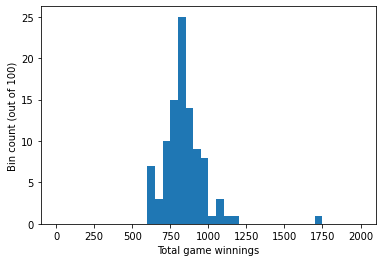

In [ ]:
#@title Plot
print(f'Mean optimal winnings: {optimal.mean():.2f} ± {ci(optimal):.2f}')
print(f'Std optimal winnings: {optimal.std():.2f}')
print(f'Min: {optimal.min()}, Max: {optimal.max()}')
print(f'% games with winnings >= 10000: {100 * (optimal >= 10000).sum() / optimal.shape[0]}')
print()
optimal_500 = optimal[optimal < 1000]
optimal_1400 = optimal[(optimal >= 1000) & (optimal < 2000)]
optimal_10000 = optimal[optimal >= 2000]

print(f'Percent games scoring < 1000:    {optimal_500.shape[0] * 100 / num_trials}% ' +
      f'(mean: {optimal_500.mean():.1f} ± {ci(optimal_500):.1f}, ' +
      f'std: {optimal_500.std():.1f})')
print(f'Percent games scoring 1000-2000:  {optimal_1400.shape[0] * 100 / num_trials}% ' +
      f'(mean: {optimal_1400.mean():.1f} ± {ci(optimal_1400):.1f}, ' +
      f'std: {optimal_1400.std():.1f})')
print(f'Percent games scoring > 2000:     {optimal_10000.shape[0] * 100 / num_trials}% ' +
      f'(mean: {optimal_10000.mean():.1f} ± {ci(optimal_10000):.1f}, ' +
      f'std: {optimal_10000.std():.1f})')
print()

_ = plt.hist(optimal, bins=40, range=(0, 2000))
#_ = plt.hist(optimal)
_ = plt.xlabel('Total game winnings')
_ = plt.ylabel(f'Bin count (out of {num_trials})')


In [ ]:
#@title Run trials (2 decks)

num_trials = 100 #@param {type:"integer"}
num_decks = 2 #@param {type:"integer"}

from tqdm.notebook import trange

optimal = np.full(num_trials, np.nan)
for trial in trange(num_trials):
  game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
  psy = psychic_solver.PsychicSolver(
          game.draw_shoe.cards, game.hand_limit, payout)
  optimal[trial] = psy.solve()[0]


  0%|          | 0/100 [00:00<?, ?it/s]

Mean optimal winnings: 416.20 ± 33.82
Std optimal winnings: 171.67
Min: 210.0, Max: 1355.0
% games with winnings >= 10000: 0.0

Percent games scoring < 1000:   97.0% (mean: 388.2 ± 13.1, std: 65.7)
Percent games scoring 1000-2000:  3.0% (mean: 1320.0 ± 35.3, std: 25.5)



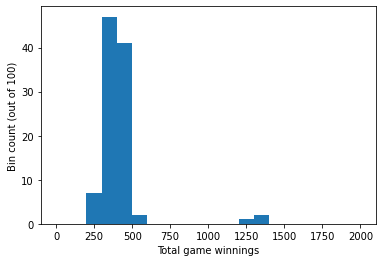

In [ ]:
#@title Plot
print(f'Mean optimal winnings: {optimal.mean():.2f} ± {ci(optimal):.2f}')
print(f'Std optimal winnings: {optimal.std():.2f}')
print(f'Min: {optimal.min()}, Max: {optimal.max()}')
print(f'% games with winnings >= 10000: {100 * (optimal >= 10000).sum() / optimal.shape[0]}')
print()
optimal_500 = optimal[optimal < 1000]
optimal_1400 = optimal[(optimal >= 1090) & (optimal < 2000)]
optimal_10000 = optimal[optimal >= 2000]

print(f'Percent games scoring < 1000:   {optimal_500.shape[0] * 100 / num_trials}% ' +
      f'(mean: {optimal_500.mean():.1f} ± {ci(optimal_500):.1f}, ' +
      f'std: {optimal_500.std():.1f})')
print(f'Percent games scoring 1000-2000:  {optimal_1400.shape[0] * 100 / num_trials}% ' +
      f'(mean: {optimal_1400.mean():.1f} ± {ci(optimal_1400):.1f}, ' +
      f'std: {optimal_1400.std():.1f})')

print()

_ = plt.hist(optimal, bins=20, range=(0, 2000))
_ = plt.xlabel('Total game winnings')
_ = plt.ylabel(f'Bin count (out of {num_trials})')


In [ ]:
#@title Run multiple games with PokerStatsAgent
num_trials = 1000 #@param {type:"integer"}

from tqdm.notebook import trange, tqdm

max_moves = hand_limit or num_decks * 52 // 5
payouts = np.full((num_trials, max_moves), np.nan)
optimal = np.full(num_trials, np.nan)
mean_num_held_ps = np.full(num_trials, np.nan)
mean_num_held_opt = np.full(num_trials, np.nan)

for trial in trange(num_trials):
  game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
  psy = psychic_solver.PsychicSolver(
          game.draw_shoe.cards, game.hand_limit, payout)
  opt_val, opt_held = psy.solve()
  optimal[trial] = opt_val

  agent = player_agent.PokerStatsAgent(game, verbose=False)
  trajectory = player_agent.play_game(game, agent)

  row = np.array([move.payout for move in trajectory])
  payouts[trial, :row.shape[0]] = row

  mean_num_held_ps[trial] = np.array(
      [gm.held.size() for gm in trajectory]).mean()
  mean_num_held_opt[trial] = np.array(
      [h.size() for h in opt_held]).mean()




  0%|          | 0/1000 [00:00<?, ?it/s]

Mean total payout: 310.175 ± 20.66
Mean payout/hand: 11.61 ± 0.78
Mean optimal payout: 947.68 ± 52.88
Mean held: PS: 2.42, Opt: 2.97


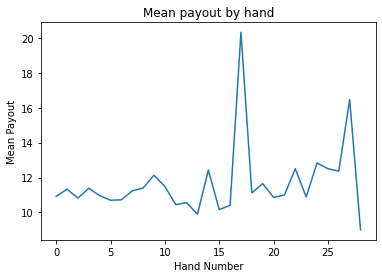

In [ ]:
#@title Compute some stats
trial_payouts = np.nansum(payouts, axis=1)
print(f'Mean total payout: {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')

payout_nonan = payouts[~np.isnan(payouts)]
print(f'Mean payout/hand: {payout_nonan.mean():.2f} ± {ci(payout_nonan):.2f}')
print(f'Mean optimal payout: {optimal.mean():.2f} ± {ci(optimal):.2f}')
print(f'Mean held: PS: {mean_num_held_ps.mean():0.2f}, Opt: {mean_num_held_opt.mean():0.2f}')

# Trim NaN columns
trimmed = payouts
while np.all(np.isnan(trimmed[:, -1])):
  trimmed = trimmed[:, :-1]

mean_payout_by_hand = np.nanmean(trimmed, axis=0)
plt.plot(mean_payout_by_hand)
plt.xlabel('Hand Number')
plt.ylabel('Mean Payout')
_ = plt.title('Mean payout by hand')


In [ ]:
#@title Run multiple games with PokerStatsAgent
import copy
from tqdm import notebook

payout = payout_table.PayoutTable.default()
hand_limit = 0
num_decks = 4


num_trials = 1000 #@param {type:"integer"}
bias = np.array([-11.,  -6.,  -2. ,   2., 6.,  11. ])
bias *= 0.5
print(bias)

max_moves = hand_limit or num_decks * 52 // 5
payouts = np.full((num_trials, max_moves), np.nan)
payouts_biased = np.full((num_trials, max_moves), np.nan)

for trial in notebook.trange(num_trials):
  game = poker_game.PokerGame(
    num_decks=num_decks, payout=payout, hand_limit=hand_limit)
  game_biased = copy.deepcopy(game)
  agent = player_agent.PokerStatsAgent(verbose=False, name='base')
  agent_biased = player_agent.PokerStatsAgent(
      verbose=False, name='biased', bias=bias)

  trajectory = player_agent.play_game(game, agent)
  trajectory_biased = player_agent.play_game(game_biased, agent_biased)
  row = np.array([move.payout for move in trajectory])
  row_biased = np.array([move.payout for move in trajectory_biased])

  payouts[trial, :row.shape[0]] = row
  payouts_biased[trial, :row_biased.shape[0]] = row_biased


[-5.5 -3.  -1.   1.   3.   5.5]


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
trial_payouts = np.nansum(payouts, axis=1)
print(f'Mean total payout:        {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')
trial_payouts_biased = np.nansum(payouts_biased, axis=1)
print(f'Mean total payout biased: {trial_payouts_biased.mean()} ± {ci(trial_payouts_biased):.2f}')


Mean total payout:        304.78 ± 7.46
Mean total payout biased: 312.905 ± 8.17


In [ ]:
trial_payouts = np.nansum(payouts, axis=1)
print(f'Mean total payout:        {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')
trial_payouts_biased = np.nansum(payouts_biased, axis=1)
print(f'Mean total payout biased: {trial_payouts_biased.mean()} ± {ci(trial_payouts_biased):.2f}')
  

Mean total payout:        305.7 ± 26.52
Mean total payout biased: 262.8 ± 25.22


In [ ]:
trial_payouts = np.nansum(payouts, axis=1)
print(f'Mean total payout:        {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')
trial_payouts_biased = np.nansum(payouts_biased, axis=1)
print(f'Mean total payout biased: {trial_payouts_biased.mean()} ± {ci(trial_payouts_biased):.2f}')
  

Mean total payout:        330.85 ± 31.87
Mean total payout biased: 265.35 ± 24.71


Mean total payout: 333.0 ± 79.35
Mean payout/hand: 12.33 ± 3.10


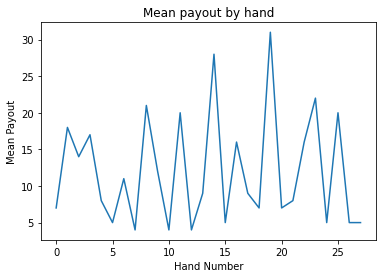

In [ ]:
#@title Compute some stats


trial_payouts = np.nansum(payouts, axis=1)
print(f'Mean total payout: {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')

payout_nonan = payouts[~np.isnan(payouts)]
print(f'Mean payout/hand: {payout_nonan.mean():.2f} ± {ci(payout_nonan):.2f}')

# Trim NaN columns
trimmed = payouts
while np.all(np.isnan(trimmed[:, -1])):
  trimmed = trimmed[:, :-1]

mean_payout_by_hand = np.nanmean(trimmed, axis=0)
plt.plot(mean_payout_by_hand)
plt.xlabel('Hand Number')
plt.ylabel('Mean Payout')
_ = plt.title('Mean payout by hand')


Mean total payout: 319.0 ± 12.93
Mean payout/hand: nan ± nan


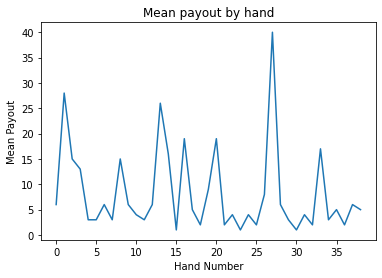

In [ ]:
#@title Compute some stats


trial_payouts = np.nansum(payouts_biased, axis=1)
print(f'Mean total payout: {trial_payouts.mean()} ± {ci(trial_payouts):.2f}')

payout_nonan = payouts[~np.isnan(payouts_biased)]
print(f'Mean payout/hand: {payout_nonan.mean():.2f} ± {ci(payout_nonan):.2f}')

# Trim NaN columns
trimmed = payouts_biased
while np.all(np.isnan(trimmed[:, -1])):
  trimmed = trimmed[:, :-1]

mean_payout_by_hand = np.nanmean(trimmed, axis=0)
plt.plot(mean_payout_by_hand)
plt.xlabel('Hand Number')
plt.ylabel('Mean Payout')
_ = plt.title('Mean payout by hand')
